In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import lfilter, remez
from scipy.constants import c
from scipy.constants import pi
from scipy import stats
from scipy import signal
from scipy import integrate
from scipy import interpolate
from astropy.io import ascii
import math as m

C:\Users\kstepancic\AppData\Local\Temp\ipykernel_2292\1687378750.py:19: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataNO2 = pd.read_csv(dataloc,delim_whitespace=True, skiprows=41,skipinitialspace=True, names = ["wl","wn","crossec","crossecErr"])


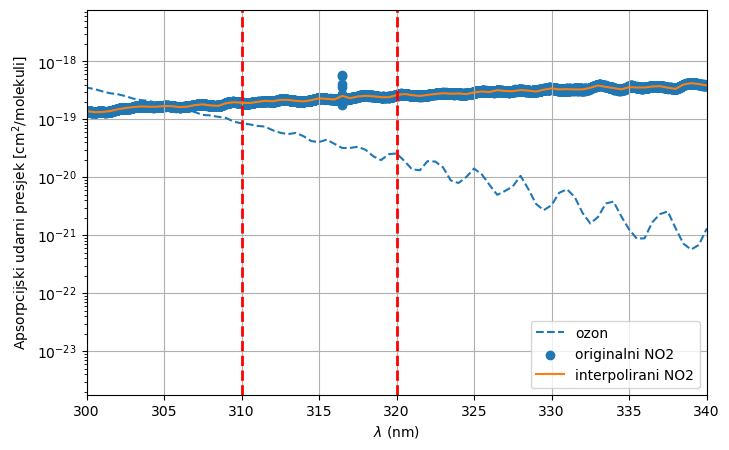

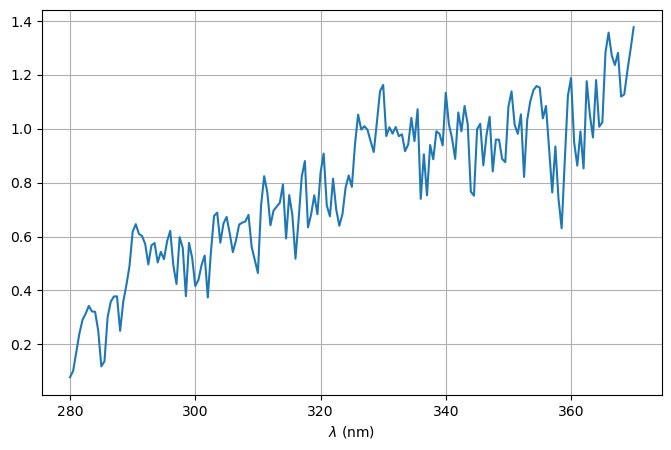

In [4]:
### --- IMPORT extraterrestrial SUNSHINE 
exterre = ascii.read("Spctrm_0.dat")
wvlgth = exterre['Wvlgth']
exterre = exterre['Gueymard_2003']
exterre = exterre[:181]
wvlgth = wvlgth[:181]/10.0

### --- IMPORT UDARNOG PRESJEKA OZONA provided by SMARTS at 228 K 
###     (ne Gorshelev koji sam koristio na završnom)
abs_O3UV = ascii.read("Abs_O3UV.dat")
Wvl_full = abs_O3UV['Wvl_nm']
Wvl_nm = Wvl_full[:341]
cross_sec_full = abs_O3UV['Ref_228K']
cross_sec = cross_sec_full[:181]

# NO2 absorption cross-section 
dataloc = 'No2_280h.dat'
# wl [nm], wn [cm-1], crossec [cm2/molec], crossecErr [cm2/molec]
dataNO2 = pd.read_csv(dataloc,delim_whitespace=True, skiprows=41,skipinitialspace=True, names = ["wl","wn","crossec","crossecErr"])

# INTERPOLACIJA udarnih presjeka za NO2 za wvlgth array
# tablica je po padajućim valnim duljinama (počine na 800 nm i ide do 250nm),
# pa ju treba flip prije nego što se radi interpolacija 
crossNO2 = np.interp(wvlgth, np.flip(dataNO2.wl), np.flip(dataNO2.crossec), left=None, right=None, period=None)

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(wvlgth , cross_sec, label='ozon',ls='--')
ax.scatter(dataNO2.wl , dataNO2.crossec, label='originalni NO2')
ax.plot(wvlgth , crossNO2, label='interpolirani NO2')
ax.set(xlim=(300,340))
ax.set(xlabel='$\lambda$ (nm)', ylabel='Apsorpcijski udarni presjek [cm$^2$/molekuli]')
ax.axvline(wvlgth[60], color='red', linestyle='--', lw=2)
ax.axvline(wvlgth[80], color='red', linestyle='--', lw=2)
ax.grid()
ax.set_yscale('log')
ax.legend(loc='best')
plt.show()

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(wvlgth , exterre, label='ozon',ls='-')
#ax.set(xlim=(300,340))
ax.set(xlabel='$\lambda$ (nm)', ylabel='')
ax.grid()
plt.show()

plt.close(fig)

### Relativna optička zračna masa

Vrlo je blizu 1/cos(zenith) ovisnosti, ali za svaki dio računa je malo različita.

Modeliranje je u obliku:
$$m_i = [\cos Z + a_{i1}Z^{a_{i2}}(a_{i3}-Z)^{a_{i4}}]^{-1}$$

$m_i$ stands for $m_R$ (Rayleigh), $m_a$ (aerosols), $m_o$ (ozone), $m_g$ (mixed gasses), $m_w$ (water vapor), $Z$ is the zenith angle and coefficients are given in the table 4.1. SMARTS paper
http://publications.energyresearch.ucf.edu/wp-content/uploads/2018/06/FSEC-PF-270-95.pdf

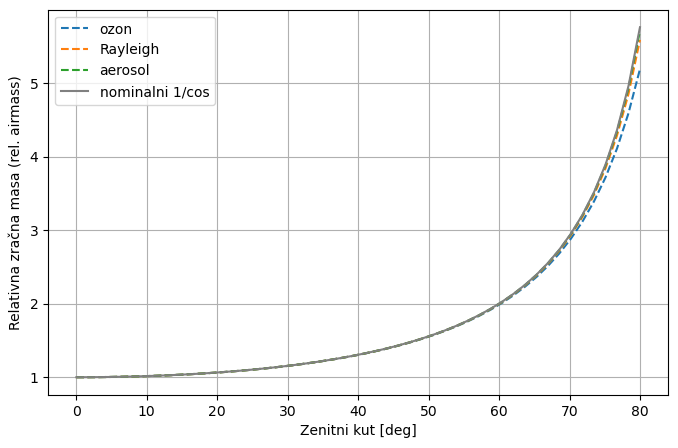

In [5]:
 # all SZA in degrees, relative optical air mass has no units
def air_mass_o(SZA): 
    a1_o = 2.6845e2        # air-mass ozone
    a2_o = 0.5
    a3_o = 115.420
    a4_o = -3.2922
    return (np.cos(np.deg2rad(SZA)) + a1_o*SZA**a2_o * (a3_o-SZA)**a4_o)**-1

def air_mass_R(SZA): 
    a1_r = 4.5665e-1       # air-mass Rayleigh scattering
    a2_r = 0.07
    a3_r = 96.4836
    a4_r = -1.6970
    return (np.cos(np.deg2rad(SZA)) + a1_r*SZA**a2_r * (a3_r-SZA)**a4_r)**-1

def air_mass_a(SZA): 
    a1_ae = 3.1141e-2      # air-mass aerosol scattering, also used for NO2
    a2_ae = 0.1
    a3_ae = 92.4710
    a4_ae = -1.3814
    return (np.cos(np.deg2rad(SZA)) + a1_ae*SZA**a2_ae * (a3_ae-SZA)**a4_ae)**-1

fig, ax = plt.subplots(figsize=(8,5))

zeniths = np.linspace(0,80,50) # iznad 80 ide do velikih vrijednosti
ax.plot(zeniths, air_mass_o(zeniths), label='ozon',ls='--')
ax.plot(zeniths, air_mass_R(zeniths), label='Rayleigh',ls='--')
ax.plot(zeniths, air_mass_a(zeniths), label='aerosol',ls='--')
ax.plot(zeniths, 1/np.cos(np.deg2rad(zeniths)), label='nominalni 1/cos',color='gray')
ax.set(xlabel='Zenitni kut [deg]', ylabel='Relativna zračna masa (rel. airmass)')

ax.grid()
ax.legend(loc='best')
plt.show()
plt.close(fig)

## Ekstinkcije 
### Ozone apsorption

Bouger law: 
$$T_{o\lambda} = \exp (-m_o\tau_{o\lambda} )$$ where 
$$\tau_{0\lambda} = u_0 A_{0\lambda}$$
is the ozone optical thickness, $m_o$ its optical mass, $u_0$ its reduced path length in (atm-cm) and $A_{0\lambda}$ its spectral absorption coefficient.

Reference temperature is $T_{ro} = 228$ K.

### Rayleigh optical thickness

Rayleigh transmittance $T_{R\lambda}$ and optical thickness $\tau_{R\lambda}$:

$$T_{R\lambda} = \exp (-m_R\tau_{R\lambda} )= \exp [
-m_R P / (a_1 \lambda^4 + a_2 \lambda^2 + a_3  + a_4 \lambda^{-2})]$$

### Aerosols extinction

Aerosol transmittance is obtained from the optical thickness: 
$$T_{a\lambda} = \exp (-m_a\tau_{a\lambda} )$$ with 
$$\tau_{a\lambda} = \beta_i (\lambda/\lambda_1)^{-\alpha_i}$$

where $\lambda_1  = 1\,\mu$m,  $m_a$ is aerosol optical mass, $\alpha_i = \alpha_1$ for $\lambda < \lambda_0$, with $ \lambda_0=0.5\,\mu$m and $\beta_i = \beta_1 = 2^{\alpha_2-\alpha_1}\beta$ for $\lambda < \lambda_0$.

Reference temperature is $T_{ro} = 228$ K.




In [6]:
psite = 1017
p0 = 1013.3

#---------------- Apsorpcija na ozonu    
# 1 DU = 0.001 atm-cm, so 0.3 atm-cm = 300 DU.
def tau_o(wvlgth,DU):
    return 2.687e16*cross_sec*DU

# -------------- Rayleighovo raspršenje
def tau_R(wvlgth):
    a1 = 117.2594*1e-12  # 117   microm^(-4)        # SMARTS calculation
    a2 = -1.3215*1e-6    # -1.32 microm^(-2)
    a3 = 3.2073e-4       # 3.2073e-4
    a4 = -7.6842e-5*1e6  # -7.68 microm^(2)
    return 1/(a1*(wvlgth)**4 + a2*(wvlgth)**2 + a3 + a4*(wvlgth)**(-2))

# -------------- Raspršenje na aerosolima -- promijenjeno na urbani
def tau_a(wvlgth):  
    alfa1 = 0.827 # urban, 50% humidity
    alfa2 = 1.171 # urban, 50% humidity
    tau_a5 = 0.3442 # SMARTS2 value
    ang_beta = tau_a5/(2**alfa2)  
    beta1 = 2**(alfa2-alfa1)*ang_beta
    lam1 = 1000 #nm 
    return beta1*(wvlgth/lam1)**(-alfa1)
    
#---------------- Apsorpcija na NO2 --ovdje se malo pogađalo, ali se dobije konzistentno
# u gradovima median 0.00166 atm-cm, raspon je 4.4e-5 do 0.013 atm-cm 
def tau_n(wvlgth,duN):
    return 2.687e16*crossNO2*duN

# Vraća zračenje Sunca nakon prolaska kroz atmosferu za zadani zenitni kut (stupnjevi)
# i stupac ozona u DU, može mu se zadati i stupac NO2 u atm-cm jedinicama, 
# pretpostavljena je niska vrijednost

def atmosphere(SZA, psite, DU, duN=1.66):
    ## RELATIVNe OPTIČKe ZRAČNe MASe
    am_o = air_mass_o(SZA)
    am_R = air_mass_R(SZA)
    am_a = air_mass_a(SZA)
    
    #-------------- Rayleighovo raspršenje
    P = psite/p0
    rayleigh = P*tau_R(wvlgth)*am_R   
    #---------------- Apsorpcija na ozonu
    ozone = tau_o(wvlgth,DU)*am_o
    #-------------- Raspršenje na aerosolima
    aerosol = tau_a(wvlgth)*am_a
    # ------------- Apsorpcija na NO2, use aerosol airmass
    no2 = tau_n(wvlgth,duN)*am_a
    
    #SURF_IRR = [x*np.exp(-y*am_o-z*am_R-k*am_a) for x,y,z,k in zip(exterre,ozone,ray,aerosol)]
    SURF_IRR = exterre*np.exp(-ozone-rayleigh-aerosol-no2) 
    return SURF_IRR

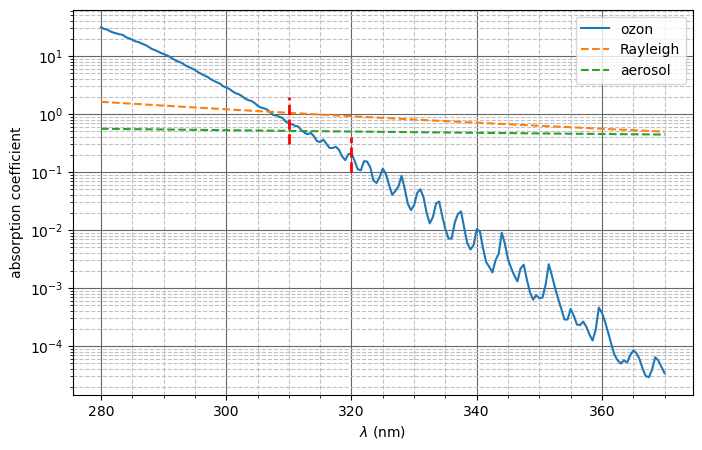


Apsorption coefficient of ozone on 310.0 nm: 0.69
Apsorption coefficient of ozone on 320.0 nm: 0.21

Apsorption coefficient of Rayleigh scattering on 310.0 nm: 1.05
Apsorption coefficient of Rayleigh scattering on 320.0 nm: 0.91

Apsorption coefficient of aerosol scattering on 310.0 nm: 0.51
Apsorption coefficient of aerosol scattering on 320.0 nm: 0.50


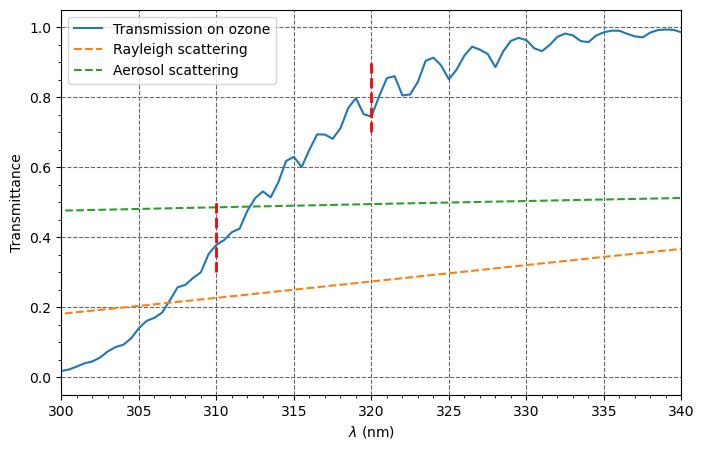


Transmission coefficient of ozone on 310.0 nm: 0.378
Transmission coefficient of ozone on 320.0 nm: 0.745

Transmission coefficient of Rayleigh scattering on 310.0 nm: 0.227
Transmission coefficient of Rayleigh scattering on 320.0 nm: 0.274

Transmission coefficient of aerosol scattering on 310.0 nm: 0.486
Transmission coefficient of aerosol scattering on 320.0 nm: 0.495


In [7]:
ozone = np.exp(-tau_o(wvlgth, 300)*air_mass_o(45))
rayleigh = np.exp(-psite/p0*tau_R(wvlgth)*air_mass_R(45))
aerosol = np.exp(-tau_a(wvlgth)*air_mass_a(45))

fig, ax = plt.subplots(figsize=(8,5))

ax.plot(wvlgth, tau_o(wvlgth, 300), label='ozon',ls='-')
ax.plot(wvlgth, tau_R(wvlgth), label='Rayleigh',ls='--')
ax.plot(wvlgth, tau_a(wvlgth), label='aerosol',ls='--')
ax.set(xlabel='$\lambda$ (nm)', ylabel='absorption coefficient')
ax.set_yscale('log')
ax.grid( which='major', color='#666666', linestyle='-')
ax.grid(which='minor', color='silver', linestyle='--')
ax.minorticks_on()
ax.legend(loc='best')

plt.vlines(x = [310, 320], ymin = [3e-1, 1e-1], ymax = [2, 4e-1],
           colors = 'red', ls='--', lw=2,
           label = 'wavelength pair')

plt.show()

print("\nApsorption coefficient of ozone on {0:0.1f} nm: {1:0.2f}\nApsorption coefficient of ozone on {2:0.1f} nm: {3:0.2f}"
      .format(wvlgth[60], tau_o(wvlgth, 300)[60], wvlgth[80], tau_o(wvlgth, 300)[80]))
print("\nApsorption coefficient of Rayleigh scattering on {0:0.1f} nm: {1:0.2f}\nApsorption coefficient of Rayleigh scattering on {2:0.1f} nm: {3:0.2f}"
      .format(wvlgth[60], tau_R(wvlgth)[60], wvlgth[80], tau_R(wvlgth)[80]))
print("\nApsorption coefficient of aerosol scattering on {0:0.1f} nm: {1:0.2f}\nApsorption coefficient of aerosol scattering on {2:0.1f} nm: {3:0.2f}"
      .format(wvlgth[60], tau_a(wvlgth)[60], wvlgth[80], tau_a(wvlgth)[80]))

fig, ax = plt.subplots(figsize=(8,5))

ax.plot(wvlgth, ozone, label='Transmission on ozone',ls='-')
ax.plot(wvlgth, rayleigh, label='Rayleigh scattering',ls='--')
ax.plot(wvlgth, aerosol, label='Aerosol scattering',ls='--')
ax.set(xlabel='$\lambda$ (nm)', ylabel='Transmittance', xlim=(300,340))
ax.grid( which='major', color='#666666', linestyle='--')
#ax.grid(which='minor', color='silver', linestyle='--')
ax.minorticks_on()
ax.legend(loc='best')

plt.vlines(x = [310, 320], ymin = [3e-1, 7e-1], ymax = [5e-1, 9e-1],
           colors = 'red', ls='--', lw=2,
           label = 'wavelength pair')

plt.show()
plt.close(fig)

print("\nTransmission coefficient of ozone on {0:0.1f} nm: {1:0.3f}\nTransmission coefficient of ozone on {2:0.1f} nm: {3:0.3f}"
      .format(wvlgth[60], ozone[60], wvlgth[80], ozone[80]))
print("\nTransmission coefficient of Rayleigh scattering on {0:0.1f} nm: {1:0.3f}\nTransmission coefficient of Rayleigh scattering on {2:0.1f} nm: {3:0.3f}"
      .format(wvlgth[60], rayleigh[60], wvlgth[80], rayleigh[80]))
print("\nTransmission coefficient of aerosol scattering on {0:0.1f} nm: {1:0.3f}\nTransmission coefficient of aerosol scattering on {2:0.1f} nm: {3:0.3f}"
      .format(wvlgth[60], aerosol[60], wvlgth[80], aerosol[80]))

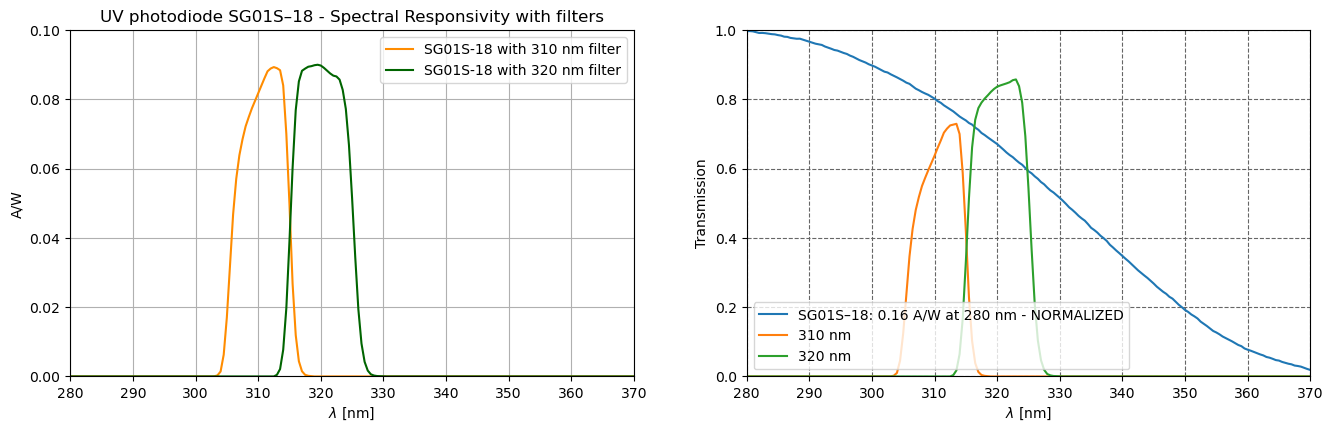

integral za detektor 1 = 0.77 [A/W]
integral za detektor 2 = 0.89 [A/W]

integral za diodu = 7.96 [A/W]
integral za filter 1 = 6.10
integral za filter 2 = 8.44

raspon valnih duljina od 280.00 do 370.00 nm

Responsivity na 310.0 nm: 0.13
Responsivity na 320.0 nm: 0.11


(0.12829033268158518, 0.10730950939605033, 1.1955169062240358)

In [8]:
### --- spektri propusnosti filtera i osjetljivosti detektora očitani u WebPlotDigitizer-u
#S = 0.06e-6 # aktivna površina 0.06 mm^2

wv1, H1 = np.loadtxt('BP310.csv', delimiter=",", dtype = 'float', unpack=True)
wv2, H2 = np.loadtxt('BP320.csv', delimiter=",", dtype = 'float', unpack=True)
wvr, responsivity = np.loadtxt('responsivity.csv', delimiter=",", dtype = 'float', unpack=True)
R = responsivity * 0.160
wv = wvr # provjereno -- sve su valne duljine iste wv1, wv2, wvr

detector1 = R * H1    # sensor * 310nm filter
detector2 = R * H2    # sensor * 320nm filter

fig, ax = plt.subplots(1,2,figsize=(16,4.5))

ax[0].plot(wvlgth, detector1, label='SG01S-18 with 310 nm filter', color='darkorange')
ax[0].plot(wvlgth, detector2, label='SG01S-18 with 320 nm filter', color='darkgreen')
ax[0].set(xlabel='$\lambda$ [nm]', ylabel='A/W', title='UV photodiode SG01S–18 - Spectral Responsivity with filters', xlim=(280,370), ylim=(0,0.1))
ax[0].grid()
ax[0].legend(loc='best')

ax[1].plot(wvlgth, responsivity, label='SG01S–18: 0.16 A/W at 280 nm - NORMALIZED')
ax[1].plot(wvlgth, H1, label='310 nm')
ax[1].plot(wvlgth, H2, label='320 nm')
ax[1].set(xlabel='$\lambda$ [nm]', ylabel='Transmission', xlim=(280,370), ylim=(0,1))
ax[1].grid( which='major', color='#666666', linestyle='--')
ax[1].legend(loc='best')

plt.show()
plt.close(fig)

print("integral za detektor 1 = {0:0.2f} [A/W]".format(integrate.simpson(R*H1,x=wvlgth)))
print("integral za detektor 2 = {0:0.2f} [A/W]".format(integrate.simpson(R*H2,x=wvlgth)))

print("\nintegral za diodu = {0:0.2f} [A/W]".format(integrate.simpson(R,x=wvlgth)))
print("integral za filter 1 = {0:0.2f}".format(integrate.simpson(H1,x=wvlgth)))
print("integral za filter 2 = {0:0.2f}".format(integrate.simpson(H2,x=wvlgth)))

print("\nraspon valnih duljina od {0:0.2f} do {1:0.2f} nm".format(wvlgth[0], wvlgth[-1]))
print("\nResponsivity na {0:0.1f} nm: {1:0.2f}\nResponsivity na {2:0.1f} nm: {3:0.2f}".format(wvlgth[60], R[60], wvlgth[80], R[80]))

R[60], R[80], R[60]/R[80]

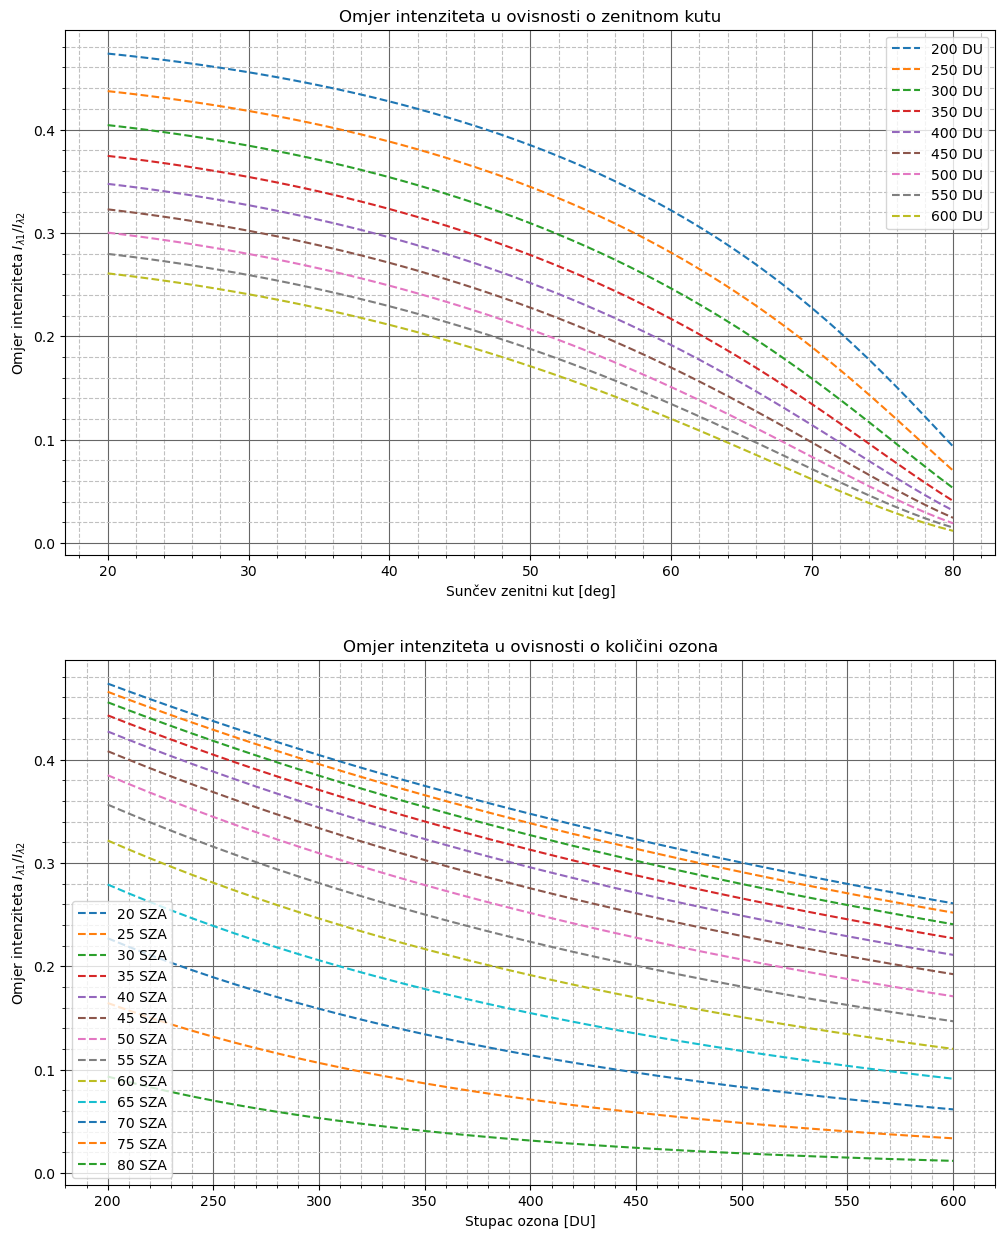

In [9]:
SZA = np.arange(20,81,1)
DU = np.arange(200,601,10)
psite=1017 #29.84*33.86389 # inHg to hPa

I1 = np.array([[integrate.simpson(atmosphere(sza,psite,du,1.66)*detector1,x=wvlgth) for sza in SZA] for du in DU])
I2 = np.array([[integrate.simpson(atmosphere(sza,psite,du,1.66)*detector2,x=wvlgth) for sza in SZA] for du in DU])
RATIO = I1/I2 # prikladna korekcija

fig, ax = plt.subplots(2,1,figsize=(12,15))
for i in range(0,len(DU),5):
    ax[0].plot(SZA, RATIO[i], linestyle='--', label="{} DU".format(DU[i]))
ax[0].set(xlabel='Sunčev zenitni kut [deg]', ylabel='Omjer intenziteta $I_{\lambda1}/I_{\lambda2}$',title='Omjer intenziteta u ovisnosti o zenitnom kutu')
ax[0].grid( which='major', color='#666666', linestyle='-')
ax[0].grid(which='minor', color='silver', linestyle='--')
ax[0].minorticks_on()
ax[0].legend(loc='best')

for i in range(0,len(SZA),5):
    ax[1].plot(DU, RATIO[:,i], linestyle='--', label="{} SZA".format(SZA[i]))
ax[1].set(xlabel='Stupac ozona [DU]', ylabel='Omjer intenziteta $I_{\lambda1}/I_{\lambda2}$',title='Omjer intenziteta u ovisnosti o količini ozona')
ax[1].grid( which='major', color='#666666', linestyle='-')
ax[1].grid(which='minor', color='silver', linestyle='--')
ax[1].minorticks_on()
ax[1].legend(loc='best')

plt.show()
plt.close(fig)

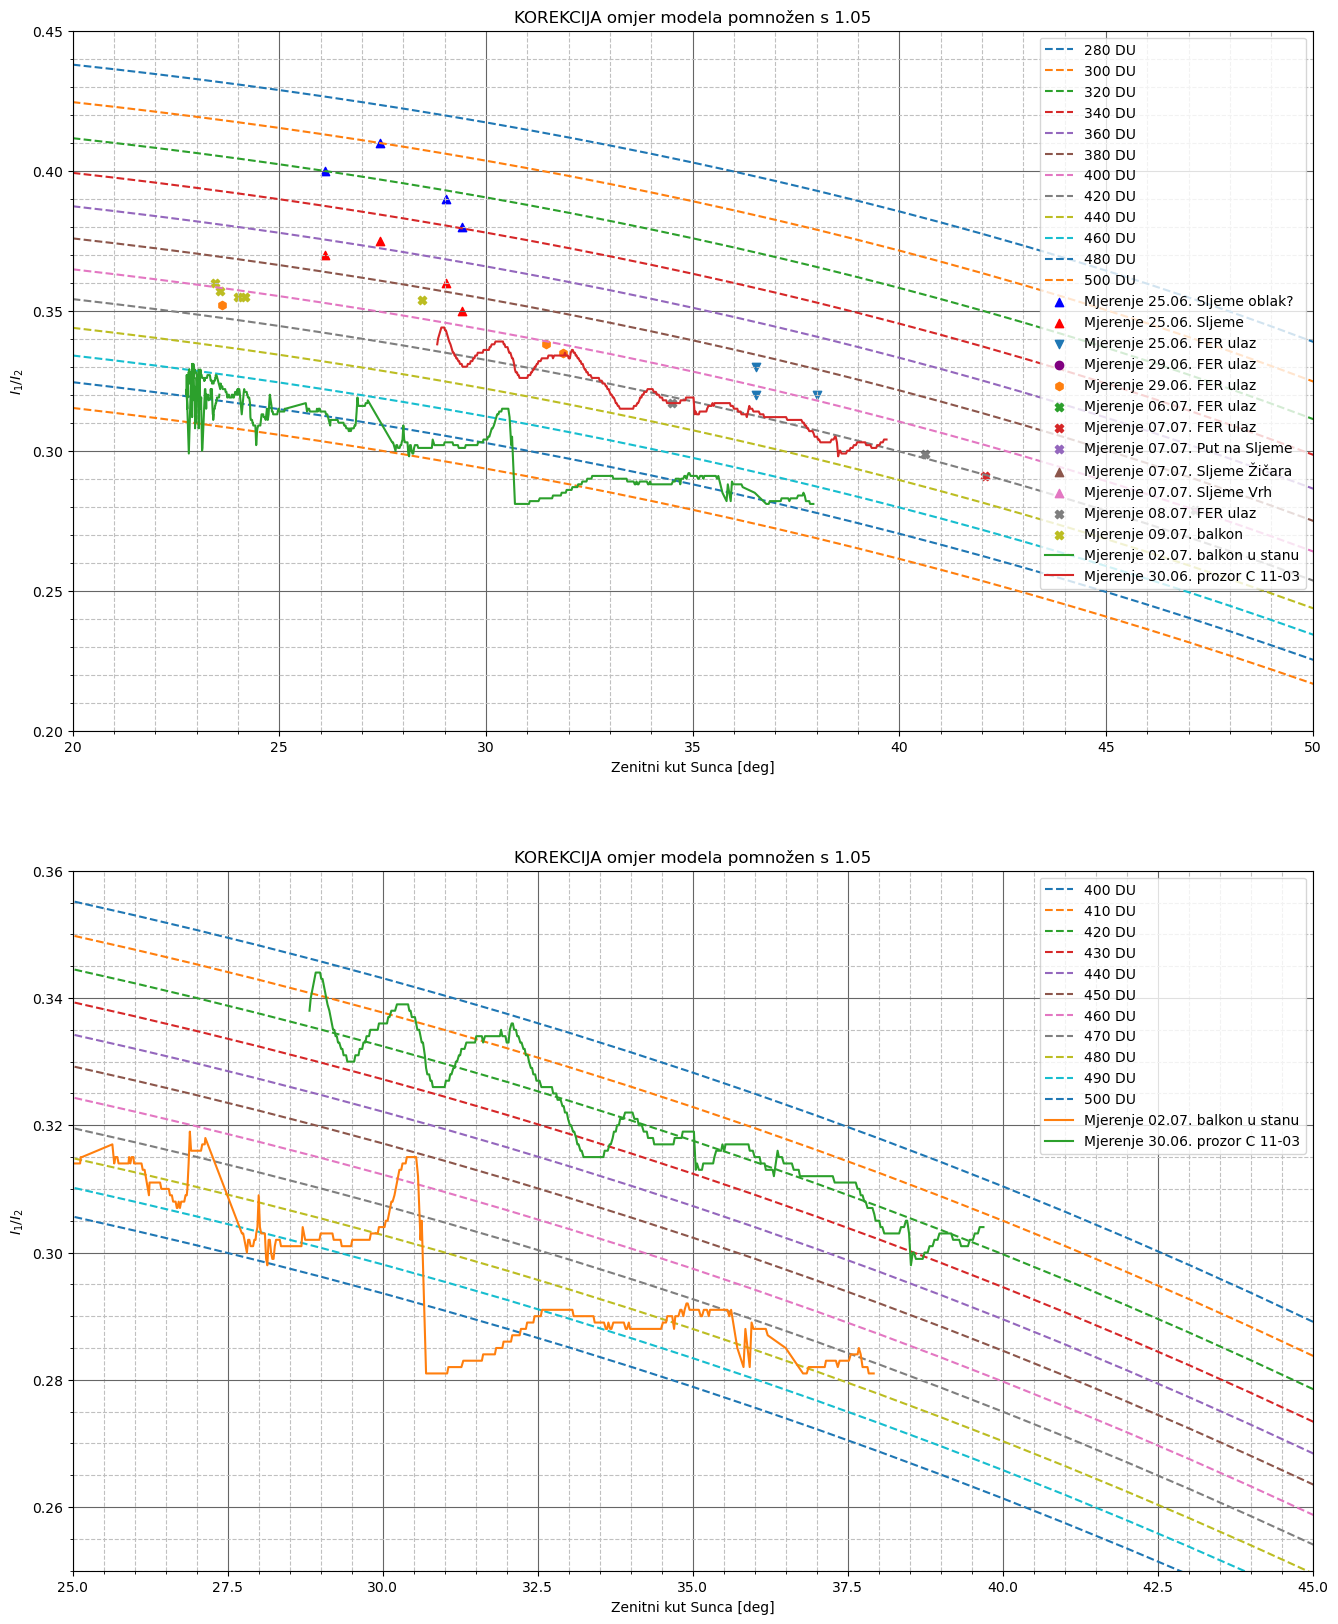

In [10]:
i, meanV1, meanV2, meanRatio, stdV1, stdV2, stdRatio, el = np.loadtxt('ozone_0207.csv', delimiter=",",
                                                                  dtype = 'float', unpack=True,skiprows=4)

I = np.logical_and(meanRatio>0.28,stdRatio<0.01)
i = i[np.where(I==True)]
meanRatio=meanRatio[np.where(I==True)]
stdRatio=stdRatio[np.where(I==True)]
el=el[np.where(I==True)]

i_1, meanV1_1, meanV2_1, meanRatio_1, stdV1_1, stdV2_1, stdRatio_1, el_1 = np.loadtxt('ozone_3006_1.csv', delimiter=",",
                                                                  dtype = 'float', unpack=True,skiprows=4)

mjerenja26_sljeme = np.array([[63.89,0.37],[62.57,0.375],[60.98,0.36],[60.59,0.35]])
mjerenje29_fer = np.array([[90-78,0.037]])
sljeme25 = np.array([[63.89,.40],[62.57,.41],[60.98,.39],[60.59,.38]])

mjerenja29 = np.array([[66.38,0.352],[58.55,0.338],[58.13,0.335],[30.25,0.193]])
mjerenja30 = np.array([[61.04,0.344],[56.7,0.315],[51.6,0.304]])

mjerenje06 = np.array([22.88,0.117])

elevations = np.array([63.89,62.57,62.57,62.57,60.98,60.98,60.59])
el_zg = np.array([53.47,53.47,52])
ratios = np.array([0.40,0.41,0.40,0.42,0.40,0.39,0.38])
ratios_zg = np.array([0.32,0.33,0.32])
zeniths = 90 - elevations
zeniths_zg = 90 - el_zg

elevations27 = np.array([59.59,62.86,65.85,66.42,66.54,66.91,66.81])
ratios27 = np.array([0.315,0.318,0.322,0.324,0.327,0.329,0.323])
zeniths27 = 90 - elevations27

mjerenje08 = np.array([[55.5,0.317],[49.39,0.299],[42.84,0.279],[34.38,0.221],[29.78,0.170],[24.28,0.129]])

# zg i put na sljeme 07.07.2023
sljeme07 = np.array([[71.33, 0.114],[68.83,0.151],[70.48,0.155],[68.43,0.162],[67.23,0.168],[67.06,0.153],[67.06,0.137],[66.72,0.183],[66.72,0.124]])
ZG = np.array([[47.93,.291],[35.29,.225],[32.16,.206]])
#sljeme_put = np.array([[31.37,.177],[29.45,.154],[28.23,.169],[25.81,.153],[24.77,.129]])
sljeme_put = np.array([[28.23,.169],[25.81,.153]])
sljeme_zicara = np.array([[23.39,.130],[23.22,.183],[23.05,.206],[22.88,.143],[22.7,.168,],[22.19,.174],[21.85,.164],[21.5,.166,],[19.97,.176],[19.8,.165],[19.46,.151]])
sljeme_vrh = np.array([[18.55,.156],[18.38,.146],[17.53,.142],[15.86,.088],[13.71,.087],[23.49,.130]])

balkon=np.array([[61.56,.354],[66,.355],[66.43,.357],[66.55,.360],[65.84,.355]])

I1 = np.array([[integrate.simpson(atmosphere(sza,psite,du,1.66)*detector1,x=wvlgth) for sza in SZA] for du in DU])
I2 = np.array([[integrate.simpson(atmosphere(sza,psite,du,1.66)*detector2,x=wvlgth) for sza in SZA] for du in DU])
RATIO = I1*1.05/I2 # prikladna korekcija

fig, ax = plt.subplots(2,1,figsize=(16,20))
for i in range(8,len(DU)-10,2):
    ax[0].plot(SZA, RATIO[i], linestyle='--', label="{} DU".format(DU[i]))
#ax[0].scatter(zeniths,ratios, marker='^', label='Mjerenje 25.06. Sljeme-Kristian')
ax[0].scatter(90-sljeme25.T[0],sljeme25.T[1], marker='^', color='blue', label='Mjerenje 25.06. Sljeme oblak?')
ax[0].scatter(90-mjerenja26_sljeme.T[0],mjerenja26_sljeme.T[1], marker='^', color='red', label='Mjerenje 25.06. Sljeme')
ax[0].scatter(zeniths_zg,ratios_zg, marker='v',label='Mjerenje 25.06. FER ulaz')
ax[0].scatter(90-mjerenje29_fer.T[0],mjerenje29_fer.T[1], color='purple', label='Mjerenje 29.06. FER ulaz')
ax[0].scatter(90-mjerenja29.T[0],mjerenja29.T[1], marker='h', label='Mjerenje 29.06. FER ulaz')
ax[0].scatter(90-mjerenje06.T[0],mjerenje06.T[1], marker='X', label='Mjerenje 06.07. FER ulaz')
ax[0].scatter(90-ZG.T[0],ZG.T[1], marker='X', label='Mjerenje 07.07. FER ulaz')
ax[0].scatter(90-sljeme_put.T[0],sljeme_put.T[1], marker='X', label='Mjerenje 07.07. Put na Sljeme')
ax[0].scatter(90-sljeme_zicara.T[0],sljeme_zicara.T[1], marker='^', label='Mjerenje 07.07. Sljeme Žičara')
ax[0].scatter(90-sljeme_vrh.T[0],sljeme_vrh.T[1], marker='^', label='Mjerenje 07.07. Sljeme Vrh')
#ax[0].scatter(sljeme07.T[0],sljeme07.T[1], marker='^', label='Mjerenje 07.07. SLJEME')
ax[0].scatter(90-mjerenje08.T[0],mjerenje08.T[1], marker='X', label='Mjerenje 08.07. FER ulaz')
ax[0].scatter(90-balkon.T[0],balkon.T[1], marker='X', label='Mjerenje 09.07. balkon ')
ax[0].plot(90-el,meanRatio, label='Mjerenje 02.07. balkon u stanu')
ax[0].plot(90-el_1,meanRatio_1, label='Mjerenje 30.06. prozor C 11-03')
ax[0].set(xlabel='Zenitni kut Sunca [deg]', ylabel='$I_1/I_2$',title='KOREKCIJA omjer modela pomnožen s 1.05',
          xlim=(20,50),ylim=(0.20,0.45))
ax[0].grid( which='major', color='#666666', linestyle='-')
ax[0].grid(which='minor', color='silver', linestyle='--')
ax[0].minorticks_on()
ax[0].legend(loc='best')

I1 = np.array([[integrate.simpson(atmosphere(sza,psite,du,1.66)*detector1,x=wvlgth) for sza in SZA] for du in DU])
I2 = np.array([[integrate.simpson(atmosphere(sza,psite,du,1.66)*detector2,x=wvlgth) for sza in SZA] for du in DU])
RATIO = I1*1.05/I2 # prikladna korekcija

for i in range(20,len(DU)-10,1):
    ax[1].plot(SZA, RATIO[i], linestyle='--', label="{} DU".format(DU[i]))
ax[1].plot(90-el,meanRatio, label='Mjerenje 02.07. balkon u stanu')
ax[1].plot(90-el_1,meanRatio_1, label='Mjerenje 30.06. prozor C 11-03')
ax[1].set(xlabel='Zenitni kut Sunca [deg]', ylabel='$I_1/I_2$',title='KOREKCIJA omjer modela pomnožen s 1.05',
          xlim=(25,45),ylim=(0.25,0.36))
ax[1].grid(which='major', color='#666666', linestyle='-')
ax[1].grid(which='minor', color='silver', linestyle='--')
ax[1].minorticks_on()
ax[1].legend(loc='best')

plt.show()
plt.close(fig)

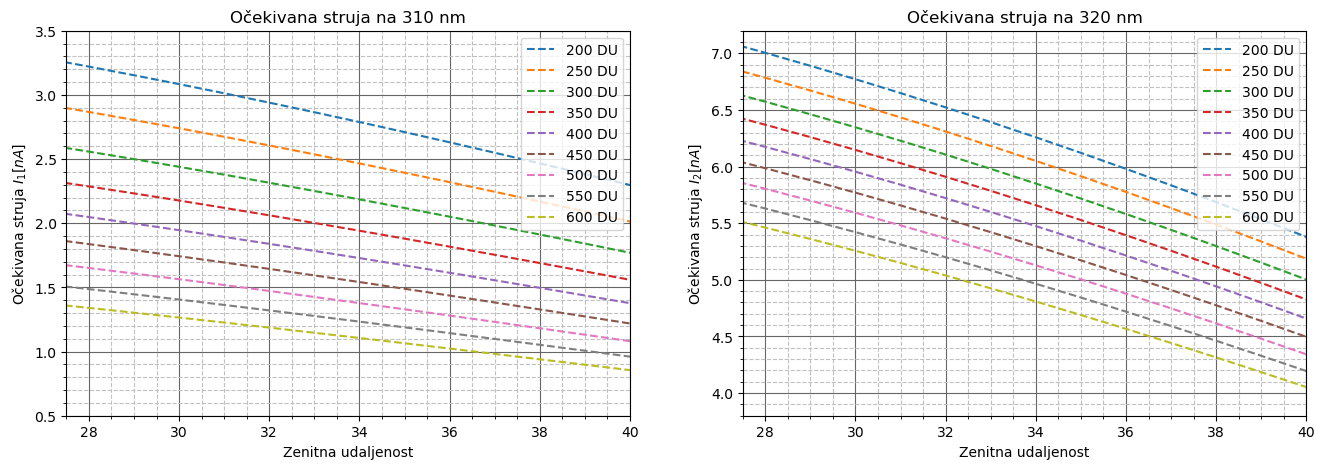

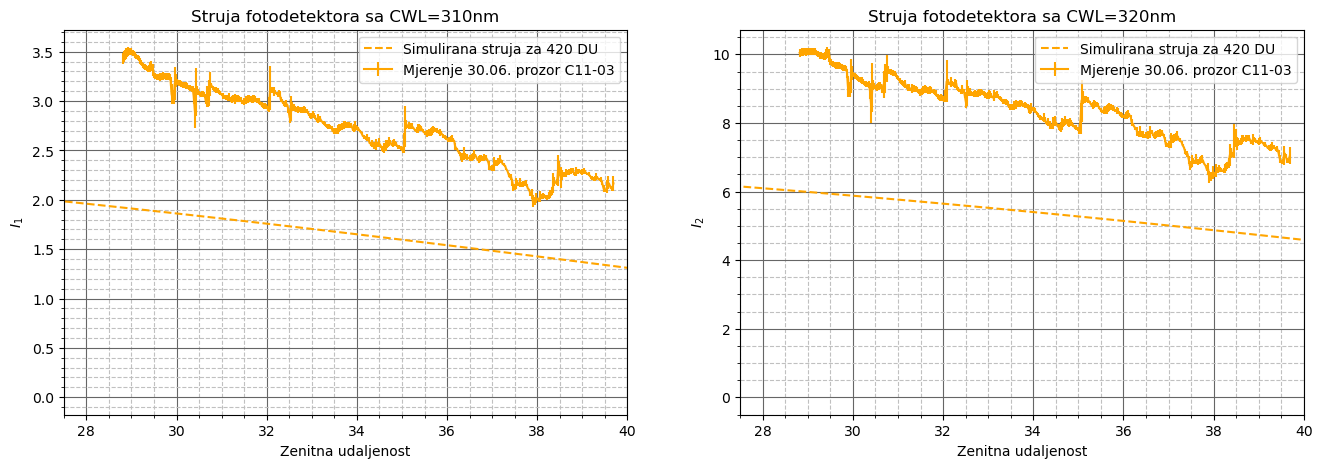

Mjerenja 30.06. (420 DU) struja na kanalu 1 je 1.66 puta veća od simulirane.
Mjerenja 02.07. (480 DU) struja na kanalu 1 je 1.66 puta veća od simulirane.
Mjerenja 30.06. (420 DU) struja na kanalu 2 je 1.56 puta veća od simulirane.
Mjerenja 02.07. (480 DU) struja na kanalu 2 je 1.56 puta veća od simulirane.


In [11]:
S = 0.06e-6 # aktivna površina 0.06 mm^2

I1 = np.array([[S*integrate.simpson(atmosphere(sza,psite,du,1.66)*detector1*1e9,x=wvlgth) for sza in SZA] for du in DU]) # u nA
I2 = np.array([[S*integrate.simpson(atmosphere(sza,psite,du,1.66)*detector2*1e9,x=wvlgth) for sza in SZA] for du in DU]) # u nA

i, meanV1, meanV2, meanRatio, stdV1, stdV2, stdRatio, el = np.loadtxt('ozone_3006_1.csv', delimiter=",",
                                                                  dtype = 'float', unpack=True,skiprows=4)
i_1, meanV1_1, meanV2_1, meanRatio_1, stdV1_1, stdV2_1, stdRatio_1, el_1 = np.loadtxt('ozone_0207.csv', delimiter=",",
                                                                  dtype = 'float', unpack=True,skiprows=5)
el_1 = el_1 - 0.2

cond = np.logical_and(meanRatio_1>0.275, meanRatio_1<0.327)
cond = np.logical_and(stdRatio_1<0.005, cond)
c1 = np.where(cond)

# 30.06.
meanI1 = meanV1 / 900e6 * 1e9 # kanal 1 u nA
stdI1 = stdV1 / 900e6 * 1e9   # kanal 1 u nA
meanI2 = meanV2 / 450e6 * 1e9 # kanal 2 u nA
stdI2 = stdV2 / 450e6 * 1e9   # kanal 2 u nA

# 02.07.
meanI1_1 = meanV1_1 / 900e6 * 1e9 # kanal 1 u nA
stdI1_1 = stdV1_1 / 900e6 * 1e9   # kanal 1 u nA
meanI2_1 = meanV2_1 / 450e6 * 1e9 # kanal 2 u nA
stdI2_1 = stdV2_1 / 450e6 * 1e9   # kanal 2 u nA

fig, ax = plt.subplots(1,2,figsize=(16,5))
for i in range(0,len(DU),5):
    ax[0].plot(SZA, I1[i], linestyle='--', label="{} DU".format(DU[i]))
ax[0].set(xlabel='Zenitna udaljenost', ylabel='Očekivana struja $I_1 [nA]$',
          title='Očekivana struja na 310 nm', xlim=(27.5,40), ylim=(0.5,3.5))
ax[0].grid( which='major', color='#666666', linestyle='-')
ax[0].grid(which='minor', color='silver', linestyle='--')
ax[0].minorticks_on()
ax[0].legend(loc='best')

for i in range(0,len(DU),5):
    ax[1].plot(SZA, I2[i], linestyle='--', label="{} DU".format(DU[i]))
ax[1].set(xlabel='Zenitna udaljenost', ylabel='Očekivana struja $I_2 [nA]$',
          title='Očekivana struja na 320 nm', xlim=(27.5,40), ylim=(3.8, 7.2))
ax[1].grid( which='major', color='#666666', linestyle='-')
ax[1].grid(which='minor', color='silver', linestyle='--')
ax[1].minorticks_on()
ax[1].legend(loc='best')

plt.show()
plt.close(fig)

fig, ax = plt.subplots(1,2,figsize=(16,5))

ax[0].plot(SZA, I1[22], linestyle='--', color='orange', label="Simulirana struja za {} DU".format(DU[22]))
ax[0].errorbar(90-el, meanI1, stdI1, linestyle='-', color='orange', label='Mjerenje 30.06. prozor C11-03')
#ax[0].plot(SZA, I1[28], linestyle='--', color='green', label="Simulirana struja za {} DU".format(DU[28]))
#ax[0].errorbar(90-el_1[c1], meanI1_1[c1], stdI1_1[c1], linestyle='-', color='green', label='Mjerenje 02.07. balkon u stanu')
ax[0].set(xlabel='Zenitna udaljenost', ylabel='$I_1$',title='Struja fotodetektora sa CWL=310nm',
          xlim=(27.5,40))
ax[0].grid(which='major', color='#666666', linestyle='-')
ax[0].grid(which='minor', color='silver', linestyle='--')
ax[0].minorticks_on()
ax[0].legend(loc='best')

ax[1].plot(SZA, I2[22], linestyle='--', color='orange', label="Simulirana struja za {} DU".format(DU[22]))
ax[1].errorbar(90-el, meanI2, stdI2, linestyle='-', color='orange', label='Mjerenje 30.06. prozor C11-03')
#ax[1].plot(SZA, I2[28], linestyle='--', color='green', label="Simulirana struja za {} DU".format(DU[28]))
#ax[1].errorbar(90-el_1[c1], meanI2_1[c1], stdI2_1[c1], linestyle='-', color='green', label='Mjerenje 02.07. balkon u stanu')
ax[1].set(xlabel='Zenitna udaljenost', ylabel='$I_2$',title='Struja fotodetektora sa CWL=320nm',
          xlim=(27.5,40))
ax[1].grid(which='major', color='#666666', linestyle='-')
ax[1].grid(which='minor', color='silver', linestyle='--')
ax[1].minorticks_on()
ax[1].legend(loc='best')

plt.show()
plt.close(fig)

#print(np.average(meanI1), np.average(I1[22][9:20]))
#print(np.average(meanI1_1), np.average(I1[28][9:19]))

print("Mjerenja 30.06. (420 DU) struja na kanalu 1 je {0:0.2f} puta veća od simulirane.\nMjerenja 02.07. (480 DU) struja na kanalu 1 je {0:0.2f} puta veća od simulirane."
      .format(np.average(meanI1)/np.average(I1[22][9:20]), np.average(meanI1_1)/np.average(I1[28][9:19])))

print("Mjerenja 30.06. (420 DU) struja na kanalu 2 je {0:0.2f} puta veća od simulirane.\nMjerenja 02.07. (480 DU) struja na kanalu 2 je {0:0.2f} puta veća od simulirane."
      .format(np.average(meanI2)/np.average(I2[22][9:20]), np.average(meanI2_1)/np.average(I2[28][9:19])))

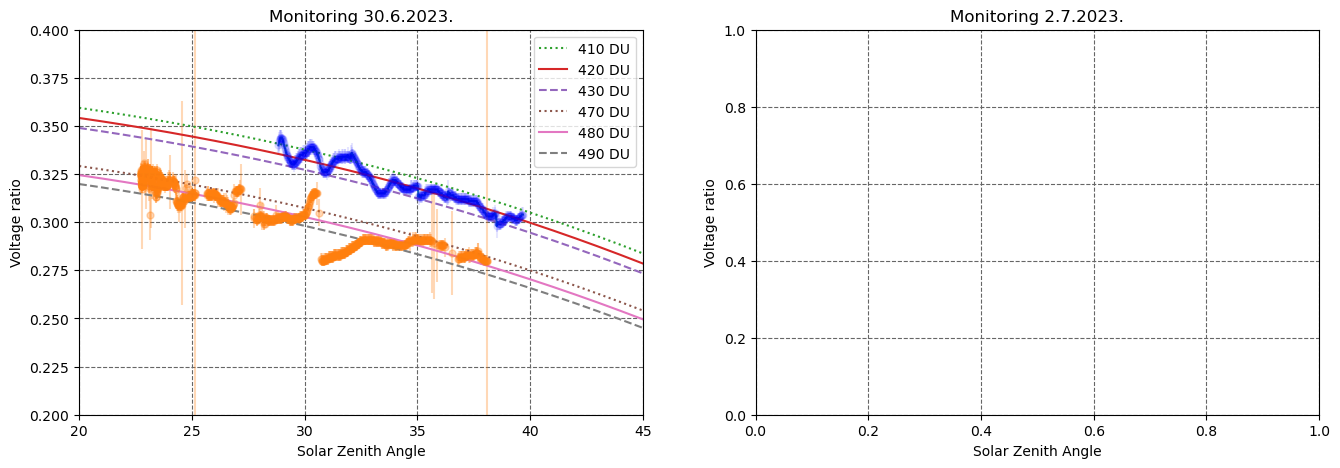

In [12]:
i, meanV1, meanV2, meanRatio, stdV1, stdV2, stdRatio, el = np.loadtxt('ozone_3006_1.csv', delimiter=",",
                                                                      dtype = 'float', unpack=True,skiprows=5)
i_1, meanV1_1, meanV2_1, meanRatio_1, stdV1_1, stdV2_1, stdRatio_1, el_1 = np.loadtxt('ozone_0207.csv', delimiter=",",dtype = 'float',
                                                                                    unpack=True,skiprows=4)

I1 = np.array([[integrate.simpson(atmosphere(sza,psite,du,1.66)*detector1,x=wvlgth) for sza in SZA] for du in DU])
I2 = np.array([[integrate.simpson(atmosphere(sza,psite,du,1.66)*detector2,x=wvlgth) for sza in SZA] for du in DU])
RATIO = I1*1.05/I2 # prikladna korekcija

fig, ax = plt.subplots(1,2,figsize=(16,5))

ax[0].plot(90-el, meanRatio, linestyle='-')
ax[0].errorbar(90-el, meanRatio, stdRatio, color='blue',ls='None',marker='o',markersize=5.,alpha=0.1)
ax[0].errorbar(90-el_1[c1], meanRatio_1[c1], stdRatio_1[c1], ls='None',marker='o',markersize=5., alpha = 0.3)

ax[0].plot(SZA, RATIO[21], linestyle=':', label="{} DU".format(DU[21]))
ax[0].plot(SZA, RATIO[22], linestyle='-', label="{} DU".format(DU[22]))
ax[0].plot(SZA, RATIO[23], linestyle='--', label="{} DU".format(DU[23]))

#ax[0].set(ylim=(0.25,0.37), xlim=(25,45))
ax[0].set(xlabel='Solar Zenith Angle', ylabel='Voltage ratio',title='Monitoring 30.6.2023.')
ax[0].grid( which='major', color='#666666', linestyle='--')
#ax[0].legend(loc='best')

cond = np.logical_and(meanRatio_1>0.275, meanRatio_1<0.327)
cond = np.logical_and(stdRatio_1<0.005, cond)
c1 = np.where(cond)

ax[0].plot(SZA, RATIO[27], linestyle=':', label="{} DU".format(DU[27]))
ax[0].plot(SZA, RATIO[28], linestyle='-', label="{} DU".format(DU[28]))
ax[0].plot(SZA, RATIO[29], linestyle='--', label="{} DU".format(DU[29]))
#ax[1].plot(90-el_1, meanRatio_1, linestyle='-')
#ax[0].errorbar(90-el_1[c1], meanRatio_1[c1], stdRatio_1[c1], ls='None',marker='o',markersize=5., alpha = 0.3)
ax[1].set(xlabel='Solar Zenith Angle', ylabel='Voltage ratio',title='Monitoring 2.7.2023.')
ax[0].set(ylim=(0.2,0.4), xlim=(20,45))
ax[1].grid( which='major', color='#666666', linestyle='--')
ax[0].legend(loc='best')

plt.show()
plt.close(fig)

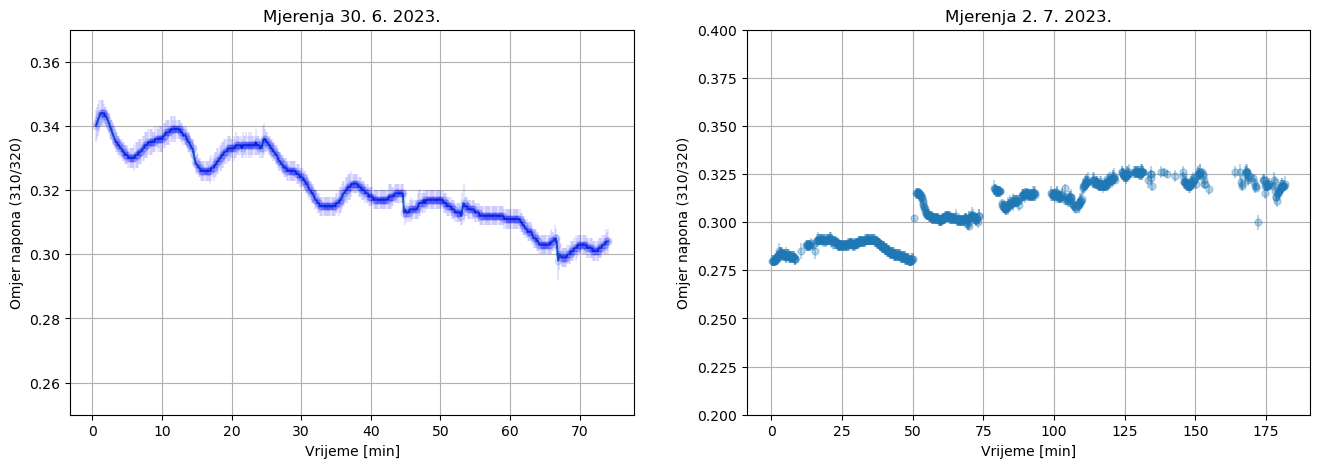

In [13]:
fig, ax = plt.subplots(1,2,figsize=(16,5))
ax[0].plot(i/60, meanRatio, linestyle='-')
ax[0].errorbar(i/60, meanRatio, stdRatio, color='blue',ls='None',marker='o',markersize=5.,alpha=0.1)
ax[0].set(ylim=(0.25,0.37))
ax[0].set(xlabel='Vrijeme [min]', ylabel='Omjer napona (310/320)',title='Mjerenja 30. 6. 2023.')
ax[0].grid()

cond = np.logical_and(meanRatio_1>0.275, meanRatio_1<0.327)
cond = np.logical_and(stdRatio_1<0.005, cond)
c1 = np.where(cond)

ax[1].errorbar(i_1[c1]/60, meanRatio_1[c1], stdRatio_1[c1], ls='None',marker='o',markersize=5., alpha = 0.3)
ax[1].set(xlabel='Vrijeme [min]', ylabel='Omjer napona (310/320)',title='Mjerenja 2. 7. 2023.')
ax[1].set(ylim=(0.2,0.4))
ax[1].grid()

plt.show()
plt.close(fig)

### Prebacivanje filtera — omjer 310/320 na istom kanalu

Kod prebacivanja filtera za svaku elevaciju imamo **20 redaka**: 10 u jednoj poziciji filtera i 10 u zamijenjenoj. Time se omjer $I_{310}/I_{320}$ može izračunati **na istom kanalu**, pa se osjetljivost fotodiode i pojačanje pojačala poništavaju.

- **omjer ch0** = (ch0 sa 310 nm) / (ch0 sa 320 nm)
- **omjer ch1** = (ch1 sa 310 nm) / (ch1 sa 320 nm)

Oba kanala mjere istu veličinu, pa je **kombinirana vrijednost njihov srednjak**, a **pogreška raste ovisno o tome koliko se slažu**: kad se poklapaju ostaje statistička, a kad se razilaze dominira polovica njihove razlike (sustavna razlika kanala). Tako 20 ulaznih vrijednosti postaje jedna točka s errorbarom na $z = 90 - $elevacija.

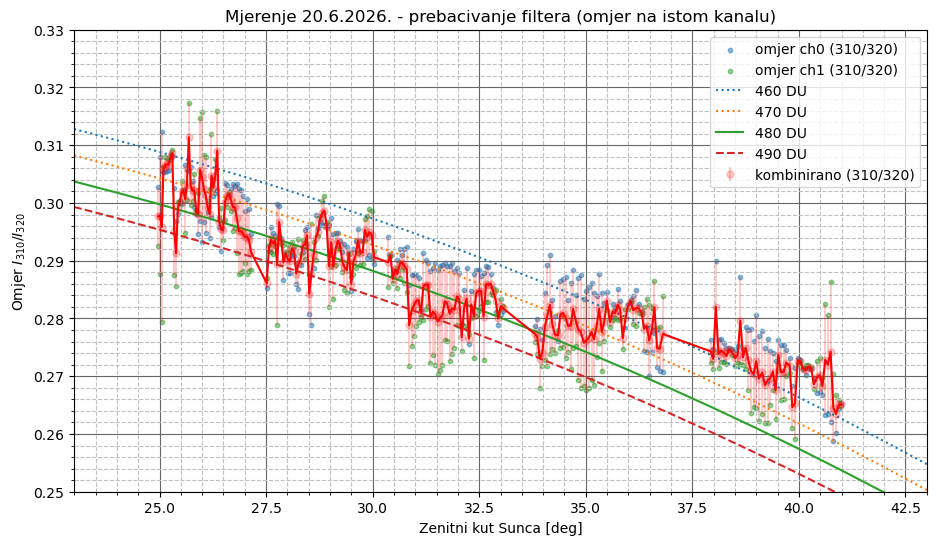

Tocaka: 248   |   medijan pogreske: 0.0031 (1.09 %)
Udio tocaka gdje se kanali razilaze (>1 sigma): 100 %


In [33]:
#####~~~~~~~~~~ FILTER-SWITCHING: omjer 310/320 na istom kanalu ~~~~~~~~~~#####
# Mjerenja s prebacivanjem filtera: za svaku elevaciju 20 redaka -> 10 u jednoj
# poziciji filtera (320 nm nad ch0, 310 nm nad ch1) i 10 u zamijenjenoj poziciji
# (310 nm nad ch0, 320 nm nad ch1). Tako se omjer 310/320 racuna NA ISTOM kanalu,
# pa se osjetljivost fotodiode i pojacanje pojacala ponistavaju.
#
# Blokove ne dijelim po redoslijedu nego po tome koji je kanal "visok" (=320 nm),
# sto je otporno i na nepotpune blokove (datoteke 3 i 5 imaju zadnji krnji blok).

psite=1019
I1 = np.array([[integrate.simpson(atmosphere(sza,psite,du,1.66)*detector1,x=wvlgth) for sza in SZA] for du in DU])
I2 = np.array([[integrate.simpson(atmosphere(sza,psite,du,1.66)*detector2,x=wvlgth) for sza in SZA] for du in DU])
R = I1/I2

def _side(vals):
    """Najbolja procjena strane bloka: srednjak 10 ocitanja + standardna pogreska srednjaka."""
    vals = np.asarray(vals, float)
    return vals.mean(), vals.std(ddof=1) / np.sqrt(len(vals))

def filter_switch_ratio(fname):
    df = pd.read_csv(fname, encoding='utf-16', skiprows=4)
    df.columns = [c.strip() for c in df.columns]
    rows = []
    for el, g in df.groupby('elevation', sort=False):
        A = g[g.mean_ch0 > g.mean_ch1]   # pozicija A: 320 nm nad ch0, 310 nm nad ch1
        B = g[g.mean_ch0 < g.mean_ch1]   # pozicija B: 310 nm nad ch0, 320 nm nad ch1
        if len(A) < 2 or len(B) < 2:
            continue                     # preskoci krnje blokove
        ch0_320, ch0_320e = _side(A.mean_ch0)   # ch0 sa 320 nm
        ch0_310, ch0_310e = _side(B.mean_ch0)   # ch0 sa 310 nm
        ch1_310, ch1_310e = _side(A.mean_ch1)   # ch1 sa 310 nm
        ch1_320, ch1_320e = _side(B.mean_ch1)   # ch1 sa 320 nm

        # omjer 310/320 zasebno po svakom kanalu (+ propagacija pogreske)
        r0  = ch0_310 / ch0_320
        r0e = r0 * np.hypot(ch0_310e/ch0_310, ch0_320e/ch0_320)
        r1  = ch1_310 / ch1_320
        r1e = r1 * np.hypot(ch1_310e/ch1_310, ch1_320e/ch1_320)

        # Kombinacija: oba kanala mjere ISTU velicinu (310/320), pa su simetricni
        # -> sredisnja vrijednost = njihov srednjak. Pogreska raste ovisno o tome
        # koliko se kanali slazu: kad se poklapaju, ostaje statisticka; kad se
        # razilaze, dominira polovica njihove razlike (sustavna razlika kanala).
        rc       = 0.5 * (r0 + r1)
        sig_stat = 0.5 * np.hypot(r0e, r1e)     # statisticka pogreska srednjaka
        sig_dis  = 0.5 * abs(r0 - r1)           # neslaganje kanala (sustavno)
        rce      = np.hypot(sig_stat, sig_dis)
        tension  = sig_dis / sig_stat if sig_stat > 0 else np.inf  # neslaganje u sigma

        rows.append((90 - el, rc, rce, r0, r1, tension))
    return np.array(rows)

files = ['mjerenje-20-6-TCP-%d.csv' % n for n in range(1, 6)]
sw = np.vstack([filter_switch_ratio(f) for f in files])
sw = sw[np.argsort(sw[:, 0])]                  # sortiraj po zenitnom kutu
z_sw, ratio_sw, ratio_sw_err = sw[:, 0], sw[:, 1], sw[:, 2]
r0_sw, r1_sw = sw[:, 3], sw[:, 4]

fig, ax = plt.subplots(figsize=(11, 6))
ax.scatter(z_sw, r0_sw, s=10, color='tab:blue',  alpha=0.5, label='omjer ch0 (310/320)')
ax.scatter(z_sw, r1_sw, s=10, color='tab:green', alpha=0.5, label='omjer ch1 (310/320)')
ax.errorbar(z_sw, ratio_sw, color='red', linestyle='-')
ax.errorbar(z_sw, ratio_sw, ratio_sw_err, color='red',ls='None',marker='o',markersize=5.,alpha=0.2, 
            label='kombinirano (310/320)')

ax.plot(SZA, R[26], linestyle=':', label="{} DU".format(DU[26]))
ax.plot(SZA, R[27], linestyle=':', label="{} DU".format(DU[27]))
ax.plot(SZA, R[28], linestyle='-', label="{} DU".format(DU[28]))
ax.plot(SZA, R[29], linestyle='--', label="{} DU".format(DU[29]))

ax.set(ylim=(0.25,0.33), xlim=(23,43))
ax.set(xlabel='Zenitni kut Sunca [deg]', ylabel='Omjer $I_{310}/I_{320}$',
       title='Mjerenje 20.6.2026. - prebacivanje filtera (omjer na istom kanalu)')
ax.grid(which='major', color='#666666', linestyle='-')
ax.grid(which='minor', color='silver', linestyle='--')
ax.minorticks_on()
ax.legend(loc='best')
plt.show()
plt.close(fig)

print('Tocaka: %d   |   medijan pogreske: %.4f (%.2f %%)'
      % (len(z_sw), np.median(ratio_sw_err), 100*np.median(ratio_sw_err/ratio_sw)))
print('Udio tocaka gdje se kanali razilaze (>1 sigma): %.0f %%' % (100*np.mean(sw[:,5] > 1)))

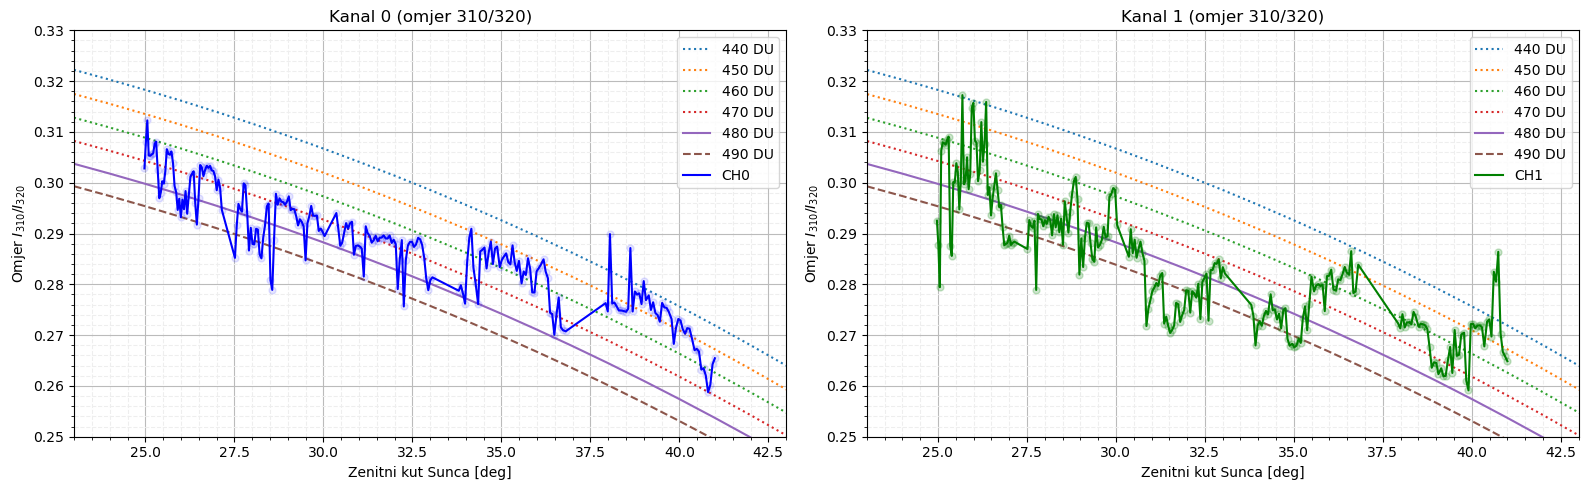

In [34]:
#####~~~~~~~~~~ Omjer 310/320 zasebno po kanalu (dva grafa) ~~~~~~~~~~#####

def filter_switch_per_channel(fname):
    df = pd.read_csv(fname, encoding='utf-16', skiprows=4)
    df.columns = [c.strip() for c in df.columns]
    rows = []
    for el, g in df.groupby('elevation', sort=False):
        A = g[g.mean_ch0 > g.mean_ch1]   # 320 nm nad ch0, 310 nm nad ch1
        B = g[g.mean_ch0 < g.mean_ch1]   # 310 nm nad ch0, 320 nm nad ch1
        if len(A) < 2 or len(B) < 2:
            continue
        ch0_320, ch0_320e = _side(A.mean_ch0)
        ch0_310, ch0_310e = _side(B.mean_ch0)
        ch1_310, ch1_310e = _side(A.mean_ch1)
        ch1_320, ch1_320e = _side(B.mean_ch1)
        r0  = ch0_310 / ch0_320
        r0e = r0 * np.hypot(ch0_310e/ch0_310, ch0_320e/ch0_320)
        r1  = ch1_310 / ch1_320
        r1e = r1 * np.hypot(ch1_310e/ch1_310, ch1_320e/ch1_320)
        rows.append((90 - el, r0, r0e, r1, r1e))
    return np.array(rows)

files = ['mjerenje-20-6-TCP-%d.csv' % n for n in range(1, 6)]
pc = np.vstack([filter_switch_per_channel(f) for f in files])
pc = pc[np.argsort(pc[:, 0])]
z_pc = pc[:, 0]
r0_pc, r0e_pc = pc[:, 1], pc[:, 2]
r1_pc, r1e_pc = pc[:, 3], pc[:, 4]

def bin_ratio(z, r, re, step=0.5):
    """Tezinski srednjak omjera po binovima zenitnog kuta sirine `step`."""
    edges = np.arange(np.floor(z.min()), np.ceil(z.max()) + step, step)
    zb, rb, reb = [], [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (z >= lo) & (z < hi)
        if m.sum() == 0:
            continue
        w = 1.0 / re[m]**2
        rmean = np.sum(w * r[m]) / np.sum(w)
        # pogreska bina: veca od statisticke (1/sqrt(sum w)) i rasapa tocaka u binu
        e_stat = np.sqrt(1.0 / np.sum(w))
        e_scat = np.std(r[m]) / np.sqrt(m.sum()) if m.sum() > 1 else 0.0
        zb.append(0.5 * (lo + hi)); rb.append(rmean); reb.append(max(e_stat, e_scat))
    return np.array(zb), np.array(rb), np.array(reb)

z0b, r0b, r0be = bin_ratio(z_pc, r0_pc, r0e_pc)
z1b, r1b, r1be = bin_ratio(z_pc, r1_pc, r1e_pc)

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

ax[0].plot(SZA, R[24], linestyle=':', label="{} DU".format(DU[24]))
ax[0].plot(SZA, R[25], linestyle=':', label="{} DU".format(DU[25]))
ax[0].plot(SZA, R[26], linestyle=':', label="{} DU".format(DU[26]))
ax[0].plot(SZA, R[27], linestyle=':', label="{} DU".format(DU[27]))
ax[0].plot(SZA, R[28], linestyle='-', label="{} DU".format(DU[28]))
ax[0].plot(SZA, R[29], linestyle='--', label="{} DU".format(DU[29]))
ax[0].plot(z_pc, r0_pc, color='blue',linestyle='-',label='CH0')
ax[0].errorbar(z_pc, r0_pc, color='blue',ls='None',marker='o',markersize=5.,alpha=0.1)
#ax[0].errorbar(z0b, r0b, r0be, ls='-', marker='o', ms=5, lw=1.5,
#               color='tab:blue', capsize=3, label='ch1 (bin 0.5°)')
ax[0].set(xlabel='Zenitni kut Sunca [deg]', ylabel='Omjer $I_{310}/I_{320}$',
          title='Kanal 0 (omjer 310/320)')
ax[0].set(ylim=(0.25,0.33), xlim=(23,43))
ax[0].grid(which='major', color='#bbbbbb', linestyle='-')
ax[0].grid(which='minor', color='#eeeeee', linestyle='--')
ax[0].minorticks_on()
ax[0].legend(loc='best')

ax[1].plot(SZA, R[24], linestyle=':', label="{} DU".format(DU[24]))
ax[1].plot(SZA, R[25], linestyle=':', label="{} DU".format(DU[25]))
ax[1].plot(SZA, R[26], linestyle=':', label="{} DU".format(DU[26]))
ax[1].plot(SZA, R[27], linestyle=':', label="{} DU".format(DU[27]))
ax[1].plot(SZA, R[28], linestyle='-', label="{} DU".format(DU[28]))
ax[1].plot(SZA, R[29], linestyle='--', label="{} DU".format(DU[29]))
ax[1].plot(z_pc, r1_pc, color='green',linestyle='-',label='CH1')
ax[1].errorbar(z_pc, r1_pc, color='green',ls='None',marker='o',markersize=5.,alpha=0.2)
#ax[1].errorbar(z1b, r1b, r1be, ls='-', marker='o', ms=5, lw=1.5,
#               color='tab:green', capsize=3, label='ch1 (bin 0.5°)')
ax[1].set(xlabel='Zenitni kut Sunca [deg]', ylabel='Omjer $I_{310}/I_{320}$',
          title='Kanal 1 (omjer 310/320)')
ax[1].set(ylim=(0.25,0.33), xlim=(23,43))
ax[1].grid(which='major', color='#bbbbbb', linestyle='-')
ax[1].grid(which='minor', color='#eeeeee', linestyle='--')
ax[1].minorticks_on()
ax[1].legend(loc='best')

plt.tight_layout()
plt.show()
plt.close(fig)

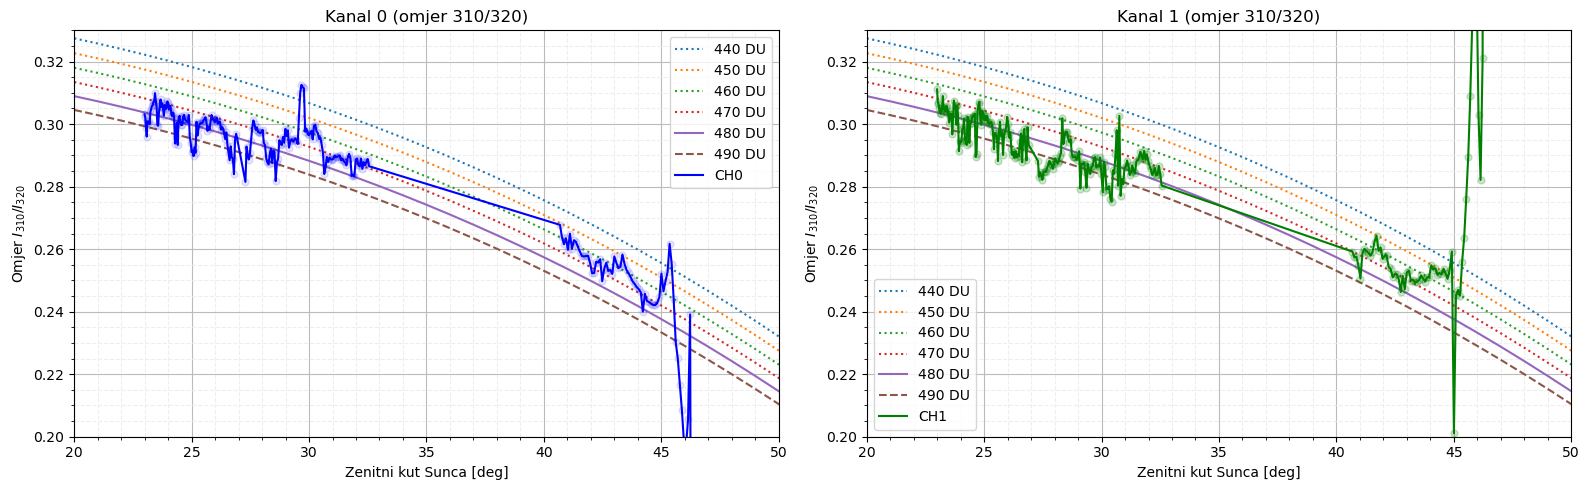

In [35]:
#####~~~~~~~~~~ Omjer 310/320 zasebno po kanalu (dva grafa) ~~~~~~~~~~#####

def filter_switch_per_channel(fname):
    df = pd.read_csv(fname, encoding='utf-16', skiprows=4)
    df.columns = [c.strip() for c in df.columns]
    rows = []
    for el, g in df.groupby('elevation', sort=False):
        A = g[g.mean_ch0 > g.mean_ch1]   # 320 nm nad ch0, 310 nm nad ch1
        B = g[g.mean_ch0 < g.mean_ch1]   # 310 nm nad ch0, 320 nm nad ch1
        if len(A) < 2 or len(B) < 2:
            continue
        ch0_320, ch0_320e = _side(A.mean_ch0)
        ch0_310, ch0_310e = _side(B.mean_ch0)
        ch1_310, ch1_310e = _side(A.mean_ch1)
        ch1_320, ch1_320e = _side(B.mean_ch1)
        r0  = ch0_310 / ch0_320
        r0e = r0 * np.hypot(ch0_310e/ch0_310, ch0_320e/ch0_320)
        r1  = ch1_310 / ch1_320
        r1e = r1 * np.hypot(ch1_310e/ch1_310, ch1_320e/ch1_320)
        rows.append((90 - el, r0, r0e, r1, r1e))
    return np.array(rows)

files = ['mjerenje-21-6-TCP-%d.csv' % n for n in range(1, 4)]
pc = np.vstack([filter_switch_per_channel(f) for f in files])
pc = pc[np.argsort(pc[:, 0])]
z_pc = pc[:, 0]
r0_pc, r0e_pc = pc[:, 1], pc[:, 2]
r1_pc, r1e_pc = pc[:, 3], pc[:, 4]

def bin_ratio(z, r, re, step=0.5):
    """Tezinski srednjak omjera po binovima zenitnog kuta sirine `step`."""
    edges = np.arange(np.floor(z.min()), np.ceil(z.max()) + step, step)
    zb, rb, reb = [], [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (z >= lo) & (z < hi)
        if m.sum() == 0:
            continue
        w = 1.0 / re[m]**2
        rmean = np.sum(w * r[m]) / np.sum(w)
        # pogreska bina: veca od statisticke (1/sqrt(sum w)) i rasapa tocaka u binu
        e_stat = np.sqrt(1.0 / np.sum(w))
        e_scat = np.std(r[m]) / np.sqrt(m.sum()) if m.sum() > 1 else 0.0
        zb.append(0.5 * (lo + hi)); rb.append(rmean); reb.append(max(e_stat, e_scat))
    return np.array(zb), np.array(rb), np.array(reb)

z0b, r0b, r0be = bin_ratio(z_pc, r0_pc, r0e_pc)
z1b, r1b, r1be = bin_ratio(z_pc, r1_pc, r1e_pc)

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

ax[0].plot(SZA, R[24], linestyle=':', label="{} DU".format(DU[24]))
ax[0].plot(SZA, R[25], linestyle=':', label="{} DU".format(DU[25]))
ax[0].plot(SZA, R[26], linestyle=':', label="{} DU".format(DU[26]))
ax[0].plot(SZA, R[27], linestyle=':', label="{} DU".format(DU[27]))
ax[0].plot(SZA, R[28], linestyle='-', label="{} DU".format(DU[28]))
ax[0].plot(SZA, R[29], linestyle='--', label="{} DU".format(DU[29]))
ax[0].plot(z_pc, r0_pc, color='blue',linestyle='-',label='CH0')
ax[0].errorbar(z_pc, r0_pc, color='blue',ls='None',marker='o',markersize=5.,alpha=0.1)
#ax[0].errorbar(z0b, r0b, r0be, ls='-', marker='o', ms=5, lw=1.5,
#               color='tab:blue', capsize=3, label='ch1 (bin 0.5°)')
ax[0].set(xlabel='Zenitni kut Sunca [deg]', ylabel='Omjer $I_{310}/I_{320}$',
          title='Kanal 0 (omjer 310/320)')
ax[0].set(ylim=(0.2,0.33), xlim=(20,50))
ax[0].grid(which='major', color='#bbbbbb', linestyle='-')
ax[0].grid(which='minor', color='#eeeeee', linestyle='--')
ax[0].minorticks_on()
ax[0].legend(loc='best')

ax[1].plot(SZA, R[24], linestyle=':', label="{} DU".format(DU[24]))
ax[1].plot(SZA, R[25], linestyle=':', label="{} DU".format(DU[25]))
ax[1].plot(SZA, R[26], linestyle=':', label="{} DU".format(DU[26]))
ax[1].plot(SZA, R[27], linestyle=':', label="{} DU".format(DU[27]))
ax[1].plot(SZA, R[28], linestyle='-', label="{} DU".format(DU[28]))
ax[1].plot(SZA, R[29], linestyle='--', label="{} DU".format(DU[29]))
ax[1].plot(z_pc, r1_pc, color='green',linestyle='-',label='CH1')
ax[1].errorbar(z_pc, r1_pc, color='green',ls='None',marker='o',markersize=5.,alpha=0.2)
#ax[1].errorbar(z1b, r1b, r1be, ls='-', marker='o', ms=5, lw=1.5,
#               color='tab:green', capsize=3, label='ch1 (bin 0.5°)')
ax[1].set(xlabel='Zenitni kut Sunca [deg]', ylabel='Omjer $I_{310}/I_{320}$',
          title='Kanal 1 (omjer 310/320)')
ax[1].set(ylim=(0.2,0.33), xlim=(20,50))
ax[1].grid(which='major', color='#bbbbbb', linestyle='-')
ax[1].grid(which='minor', color='#eeeeee', linestyle='--')
ax[1].minorticks_on()
ax[1].legend(loc='best')

plt.tight_layout()
plt.show()
plt.close(fig)

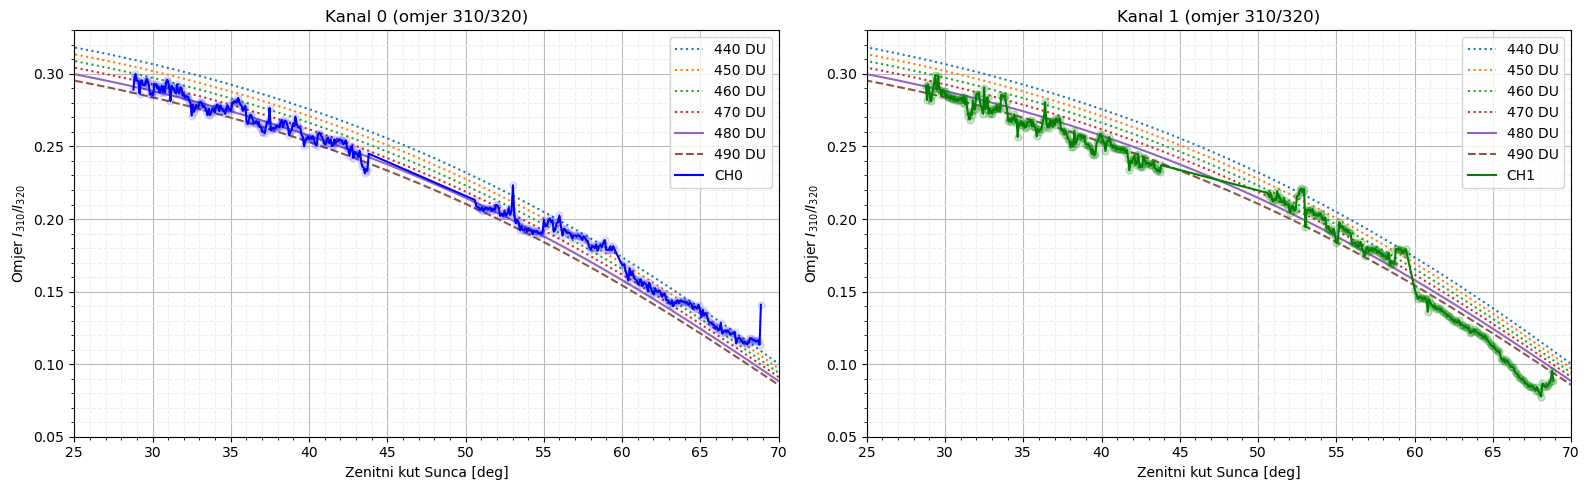

In [36]:
#####~~~~~~~~~~ Omjer 310/320 zasebno po kanalu (dva grafa) ~~~~~~~~~~#####

def filter_switch_per_channel(fname):
    df = pd.read_csv(fname, encoding='utf-16', skiprows=4)
    df.columns = [c.strip() for c in df.columns]
    rows = []
    for el, g in df.groupby('elevation', sort=False):
        A = g[g.mean_ch0 > g.mean_ch1]   # 320 nm nad ch0, 310 nm nad ch1
        B = g[g.mean_ch0 < g.mean_ch1]   # 310 nm nad ch0, 320 nm nad ch1
        if len(A) < 2 or len(B) < 2:
            continue
        ch0_320, ch0_320e = _side(A.mean_ch0)
        ch0_310, ch0_310e = _side(B.mean_ch0)
        ch1_310, ch1_310e = _side(A.mean_ch1)
        ch1_320, ch1_320e = _side(B.mean_ch1)
        r0  = ch0_310 / ch0_320
        r0e = r0 * np.hypot(ch0_310e/ch0_310, ch0_320e/ch0_320)
        r1  = ch1_310 / ch1_320
        r1e = r1 * np.hypot(ch1_310e/ch1_310, ch1_320e/ch1_320)
        rows.append((90 - el, r0, r0e, r1, r1e))
    return np.array(rows)

files = ['mjerenje-22-6-TCP-%d.csv' % n for n in range(1, 4)]
pc = np.vstack([filter_switch_per_channel(f) for f in files])
pc = pc[np.argsort(pc[:, 0])]
z_pc = pc[:, 0]
r0_pc, r0e_pc = pc[:, 1], pc[:, 2]
r1_pc, r1e_pc = pc[:, 3], pc[:, 4]

def bin_ratio(z, r, re, step=0.5):
    """Tezinski srednjak omjera po binovima zenitnog kuta sirine `step`."""
    edges = np.arange(np.floor(z.min()), np.ceil(z.max()) + step, step)
    zb, rb, reb = [], [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (z >= lo) & (z < hi)
        if m.sum() == 0:
            continue
        w = 1.0 / re[m]**2
        rmean = np.sum(w * r[m]) / np.sum(w)
        # pogreska bina: veca od statisticke (1/sqrt(sum w)) i rasapa tocaka u binu
        e_stat = np.sqrt(1.0 / np.sum(w))
        e_scat = np.std(r[m]) / np.sqrt(m.sum()) if m.sum() > 1 else 0.0
        zb.append(0.5 * (lo + hi)); rb.append(rmean); reb.append(max(e_stat, e_scat))
    return np.array(zb), np.array(rb), np.array(reb)

z0b, r0b, r0be = bin_ratio(z_pc, r0_pc, r0e_pc)
z1b, r1b, r1be = bin_ratio(z_pc, r1_pc, r1e_pc)

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

ax[0].plot(SZA, R[24], linestyle=':', label="{} DU".format(DU[24]))
ax[0].plot(SZA, R[25], linestyle=':', label="{} DU".format(DU[25]))
ax[0].plot(SZA, R[26], linestyle=':', label="{} DU".format(DU[26]))
ax[0].plot(SZA, R[27], linestyle=':', label="{} DU".format(DU[27]))
ax[0].plot(SZA, R[28], linestyle='-', label="{} DU".format(DU[28]))
ax[0].plot(SZA, R[29], linestyle='--', label="{} DU".format(DU[29]))
ax[0].plot(z_pc, r0_pc, color='blue',linestyle='-',label='CH0')
ax[0].errorbar(z_pc, r0_pc, color='blue',ls='None',marker='o',markersize=5.,alpha=0.1)
#ax[0].errorbar(z0b, r0b, r0be, ls='-', marker='o', ms=5, lw=1.5,
#               color='tab:blue', capsize=3, label='ch1 (bin 0.5°)')
ax[0].set(xlabel='Zenitni kut Sunca [deg]', ylabel='Omjer $I_{310}/I_{320}$',
          title='Kanal 0 (omjer 310/320)')
ax[0].set(ylim=(0.05,0.33), xlim=(25,70))
ax[0].grid(which='major', color='#bbbbbb', linestyle='-')
ax[0].grid(which='minor', color='#eeeeee', linestyle='--')
ax[0].minorticks_on()
ax[0].legend(loc='best')

ax[1].plot(SZA, R[24], linestyle=':', label="{} DU".format(DU[24]))
ax[1].plot(SZA, R[25], linestyle=':', label="{} DU".format(DU[25]))
ax[1].plot(SZA, R[26], linestyle=':', label="{} DU".format(DU[26]))
ax[1].plot(SZA, R[27], linestyle=':', label="{} DU".format(DU[27]))
ax[1].plot(SZA, R[28], linestyle='-', label="{} DU".format(DU[28]))
ax[1].plot(SZA, R[29], linestyle='--', label="{} DU".format(DU[29]))
ax[1].plot(z_pc, r1_pc, color='green',linestyle='-',label='CH1')
ax[1].errorbar(z_pc, r1_pc, color='green',ls='None',marker='o',markersize=5.,alpha=0.2)
#ax[1].errorbar(z1b, r1b, r1be, ls='-', marker='o', ms=5, lw=1.5,
#               color='tab:green', capsize=3, label='ch1 (bin 0.5°)')
ax[1].set(xlabel='Zenitni kut Sunca [deg]', ylabel='Omjer $I_{310}/I_{320}$',
          title='Kanal 1 (omjer 310/320)')
ax[1].set(ylim=(0.05,0.33), xlim=(25,70))
ax[1].grid(which='major', color='#bbbbbb', linestyle='-')
ax[1].grid(which='minor', color='#eeeeee', linestyle='--')
ax[1].minorticks_on()
ax[1].legend(loc='best')

plt.tight_layout()
plt.show()
plt.close(fig)

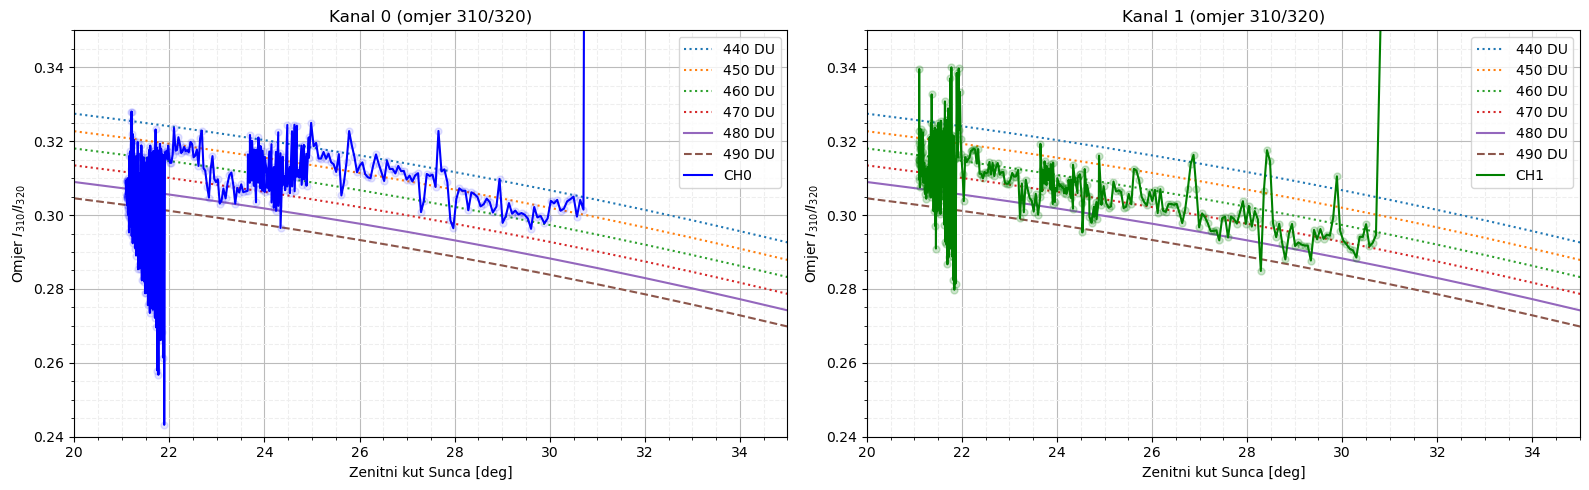

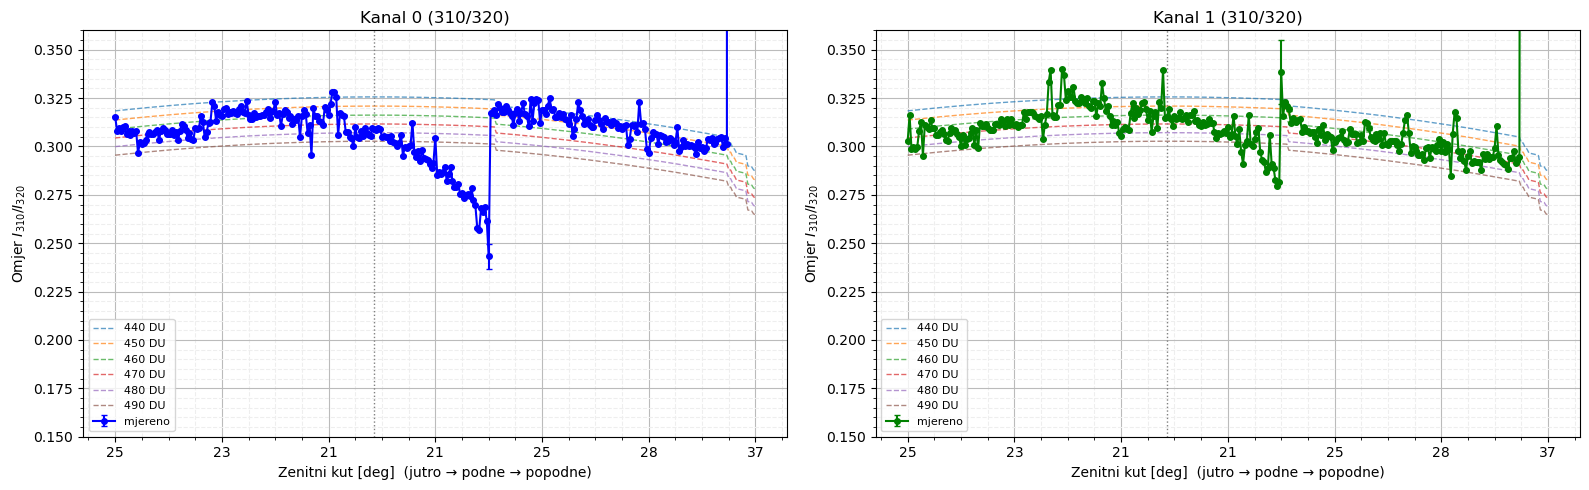

In [38]:
#####~~~~~~~~~~ Omjer 310/320 zasebno po kanalu (dva grafa) ~~~~~~~~~~#####

def filter_switch_per_channel(fname):
    df = pd.read_csv(fname, encoding='utf-16', skiprows=4)
    df.columns = [c.strip() for c in df.columns]
    rows = []
    for el, g in df.groupby('elevation', sort=False):
        A = g[g.mean_ch0 > g.mean_ch1]   # 320 nm nad ch0, 310 nm nad ch1
        B = g[g.mean_ch0 < g.mean_ch1]   # 310 nm nad ch0, 320 nm nad ch1
        if len(A) < 2 or len(B) < 2:
            continue
        ch0_320, ch0_320e = _side(A.mean_ch0)
        ch0_310, ch0_310e = _side(B.mean_ch0)
        ch1_310, ch1_310e = _side(A.mean_ch1)
        ch1_320, ch1_320e = _side(B.mean_ch1)
        r0  = ch0_310 / ch0_320
        r0e = r0 * np.hypot(ch0_310e/ch0_310, ch0_320e/ch0_320)
        r1  = ch1_310 / ch1_320
        r1e = r1 * np.hypot(ch1_310e/ch1_310, ch1_320e/ch1_320)
        rows.append((90 - el, r0, r0e, r1, r1e))
    return np.array(rows)

files = ['mjerenje-23-6-TCP-%d.csv' % n for n in range(1, 3)]
pc = np.vstack([filter_switch_per_channel(f) for f in files])
pc = pc[np.argsort(pc[:, 0])]
z_pc = pc[:, 0]
r0_pc, r0e_pc = pc[:, 1], pc[:, 2]
r1_pc, r1e_pc = pc[:, 3], pc[:, 4]

def bin_ratio(z, r, re, step=0.5):
    """Tezinski srednjak omjera po binovima zenitnog kuta sirine `step`."""
    edges = np.arange(np.floor(z.min()), np.ceil(z.max()) + step, step)
    zb, rb, reb = [], [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (z >= lo) & (z < hi)
        if m.sum() == 0:
            continue
        w = 1.0 / re[m]**2
        rmean = np.sum(w * r[m]) / np.sum(w)
        # pogreska bina: veca od statisticke (1/sqrt(sum w)) i rasapa tocaka u binu
        e_stat = np.sqrt(1.0 / np.sum(w))
        e_scat = np.std(r[m]) / np.sqrt(m.sum()) if m.sum() > 1 else 0.0
        zb.append(0.5 * (lo + hi)); rb.append(rmean); reb.append(max(e_stat, e_scat))
    return np.array(zb), np.array(rb), np.array(reb)

z0b, r0b, r0be = bin_ratio(z_pc, r0_pc, r0e_pc)
z1b, r1b, r1be = bin_ratio(z_pc, r1_pc, r1e_pc)

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

ax[0].plot(SZA, R[24], linestyle=':', label="{} DU".format(DU[24]))
ax[0].plot(SZA, R[25], linestyle=':', label="{} DU".format(DU[25]))
ax[0].plot(SZA, R[26], linestyle=':', label="{} DU".format(DU[26]))
ax[0].plot(SZA, R[27], linestyle=':', label="{} DU".format(DU[27]))
ax[0].plot(SZA, R[28], linestyle='-', label="{} DU".format(DU[28]))
ax[0].plot(SZA, R[29], linestyle='--', label="{} DU".format(DU[29]))
ax[0].plot(z_pc, r0_pc, color='blue',linestyle='-',label='CH0')
ax[0].errorbar(z_pc, r0_pc, color='blue',ls='None',marker='o',markersize=5.,alpha=0.1)
#ax[0].errorbar(z0b, r0b, r0be, ls='-', marker='o', ms=5, lw=1.5,
#               color='tab:blue', capsize=3, label='ch1 (bin 0.5°)')
ax[0].set(xlabel='Zenitni kut Sunca [deg]', ylabel='Omjer $I_{310}/I_{320}$',
          title='Kanal 0 (omjer 310/320)')
ax[0].set(ylim=(0.24,0.35), xlim=(20,35))
ax[0].grid(which='major', color='#bbbbbb', linestyle='-')
ax[0].grid(which='minor', color='#eeeeee', linestyle='--')
ax[0].minorticks_on()
ax[0].legend(loc='best')

ax[1].plot(SZA, R[24], linestyle=':', label="{} DU".format(DU[24]))
ax[1].plot(SZA, R[25], linestyle=':', label="{} DU".format(DU[25]))
ax[1].plot(SZA, R[26], linestyle=':', label="{} DU".format(DU[26]))
ax[1].plot(SZA, R[27], linestyle=':', label="{} DU".format(DU[27]))
ax[1].plot(SZA, R[28], linestyle='-', label="{} DU".format(DU[28]))
ax[1].plot(SZA, R[29], linestyle='--', label="{} DU".format(DU[29]))
ax[1].plot(z_pc, r1_pc, color='green',linestyle='-',label='CH1')
ax[1].errorbar(z_pc, r1_pc, color='green',ls='None',marker='o',markersize=5.,alpha=0.2)
#ax[1].errorbar(z1b, r1b, r1be, ls='-', marker='o', ms=5, lw=1.5,
#               color='tab:green', capsize=3, label='ch1 (bin 0.5°)')
ax[1].set(xlabel='Zenitni kut Sunca [deg]', ylabel='Omjer $I_{310}/I_{320}$',
          title='Kanal 1 (omjer 310/320)')
ax[1].set(ylim=(0.24,0.35), xlim=(20,35))
ax[1].grid(which='major', color='#bbbbbb', linestyle='-')
ax[1].grid(which='minor', color='#eeeeee', linestyle='--')
ax[1].minorticks_on()
ax[1].legend(loc='best')

plt.tight_layout()
plt.show()

# KRONOLOSKI red (NE sortiramo po zenitu) -> zenit pada do podneva pa opet raste
pc = np.vstack([filter_switch_per_channel(f) for f in files])
z_pc = pc[:, 0]
r0_pc, r0e_pc = pc[:, 1], pc[:, 2]
r1_pc, r1e_pc = pc[:, 3], pc[:, 4]

idx  = np.arange(len(z_pc))      # kronoloska os (zamjena za vrijeme)
noon = int(np.argmin(z_pc))      # solarni podne ~ najmanji zenitni kut

# model R(SZA) interpoliran na stvarni zenit svake tocke -> prati istu V-putanju
def model_at(i):
    return np.interp(z_pc, SZA, R[i])

def panel(ax, r, re, color, title):
    for i in (24, 25, 26, 27, 28, 29):
        ax.plot(idx, model_at(i), ls='--', lw=1, alpha=.7, label="{} DU".format(DU[i]))
    ax.errorbar(idx, r, re, color=color, ls='-', marker='o', ms=4, capsize=2, label='mjereno')
    ax.axvline(noon, color='gray', ls=':', lw=1)
    # x-os: kronoloska, ali oznake pokazuju zenitni kut (pada pa raste)
    ti = np.linspace(0, len(idx) - 1, 7).astype(int)
    ax.set_xticks(ti); ax.set_xticklabels(['%.0f' % z_pc[k] for k in ti])
    ax.set(xlabel='Zenitni kut [deg]  (jutro \u2192 podne \u2192 popodne)',
           ylabel='Omjer $I_{310}/I_{320}$', title=title, ylim=(0.15, 0.36))
    ax.grid(which='major', color='#bbbbbb', ls='-')
    ax.grid(which='minor', color='#eeeeee', ls='--'); ax.minorticks_on()
    ax.legend(loc='best', fontsize=8)

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
panel(ax[0], r0_pc, r0e_pc, 'blue',  'Kanal 0 (310/320)')
panel(ax[1], r1_pc, r1e_pc, 'green', 'Kanal 1 (310/320)')
plt.tight_layout(); plt.show(); plt.close(fig)

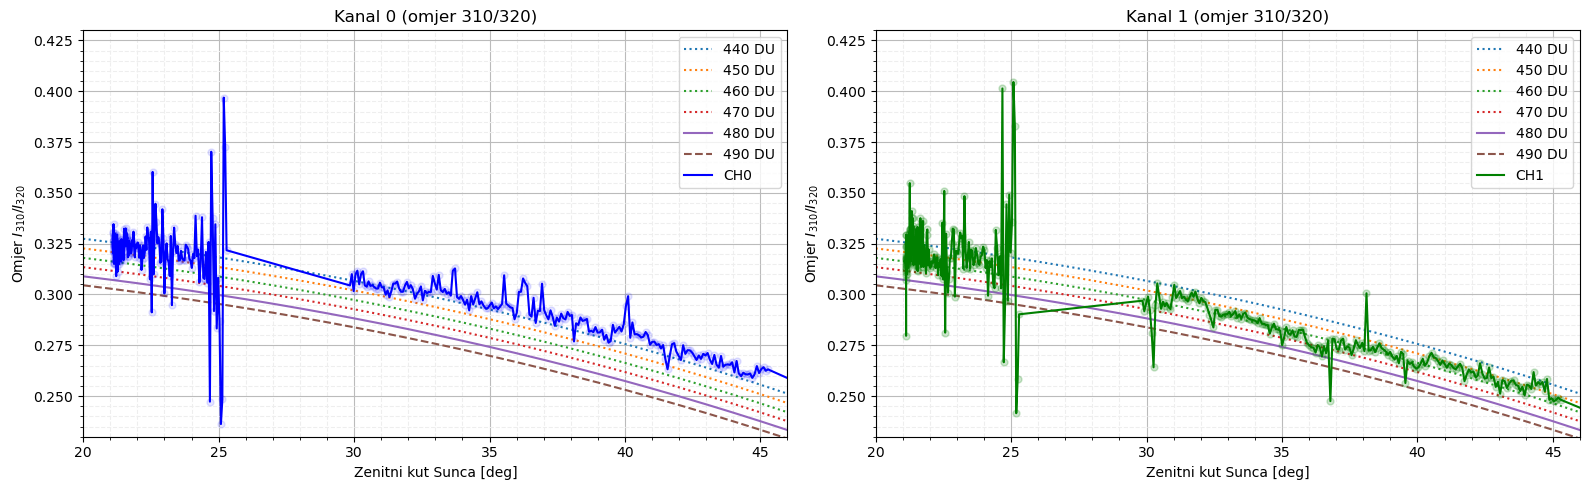

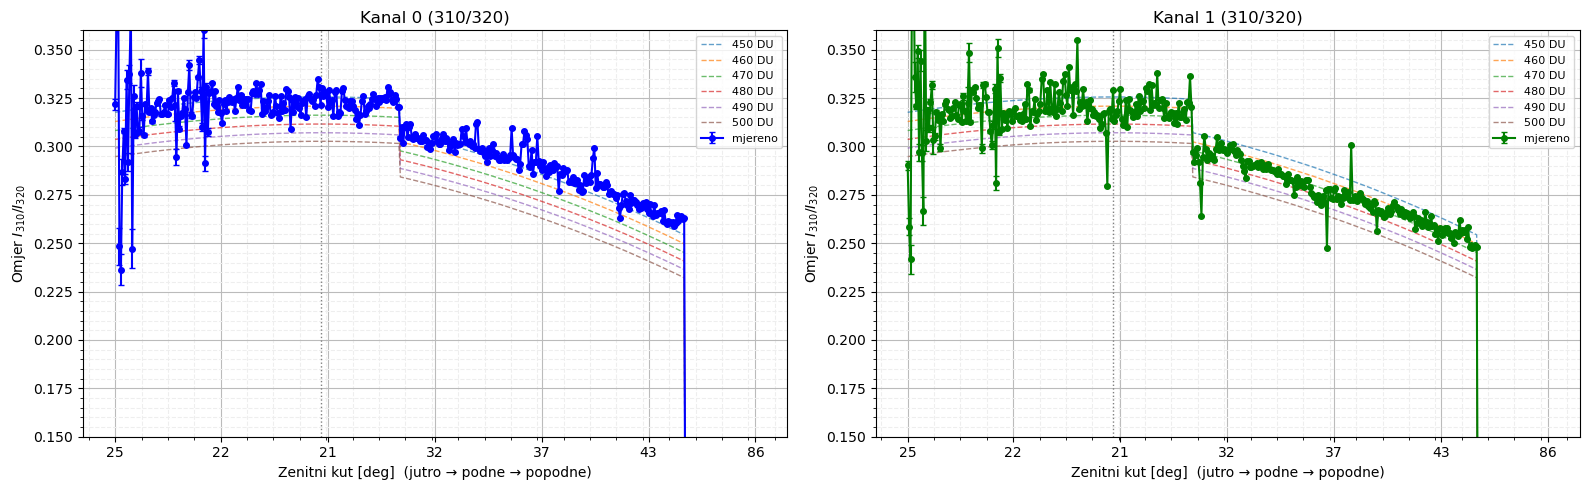

In [39]:
#####~~~~~~~~~~ Omjer 310/320 zasebno po kanalu (dva grafa) ~~~~~~~~~~#####

def filter_switch_per_channel(fname):
    df = pd.read_csv(fname, encoding='utf-16', skiprows=4)
    df.columns = [c.strip() for c in df.columns]
    rows = []
    for el, g in df.groupby('elevation', sort=False):
        A = g[g.mean_ch0 > g.mean_ch1]   # 320 nm nad ch0, 310 nm nad ch1
        B = g[g.mean_ch0 < g.mean_ch1]   # 310 nm nad ch0, 320 nm nad ch1
        if len(A) < 2 or len(B) < 2:
            continue
        ch0_320, ch0_320e = _side(A.mean_ch0)
        ch0_310, ch0_310e = _side(B.mean_ch0)
        ch1_310, ch1_310e = _side(A.mean_ch1)
        ch1_320, ch1_320e = _side(B.mean_ch1)
        r0  = ch0_310 / ch0_320
        r0e = r0 * np.hypot(ch0_310e/ch0_310, ch0_320e/ch0_320)
        r1  = ch1_310 / ch1_320
        r1e = r1 * np.hypot(ch1_310e/ch1_310, ch1_320e/ch1_320)
        rows.append((90 - el, r0, r0e, r1, r1e))
    return np.array(rows)

files = ['mjerenje-24-6-TCP-%d.csv' % n for n in range(1, 4)]
pc = np.vstack([filter_switch_per_channel(f) for f in files])
pc = pc[np.argsort(pc[:, 0])]
z_pc = pc[:, 0]
r0_pc, r0e_pc = pc[:, 1], pc[:, 2]
r1_pc, r1e_pc = pc[:, 3], pc[:, 4]

def bin_ratio(z, r, re, step=0.5):
    """Tezinski srednjak omjera po binovima zenitnog kuta sirine `step`."""
    edges = np.arange(np.floor(z.min()), np.ceil(z.max()) + step, step)
    zb, rb, reb = [], [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (z >= lo) & (z < hi)
        if m.sum() == 0:
            continue
        w = 1.0 / re[m]**2
        rmean = np.sum(w * r[m]) / np.sum(w)
        # pogreska bina: veca od statisticke (1/sqrt(sum w)) i rasapa tocaka u binu
        e_stat = np.sqrt(1.0 / np.sum(w))
        e_scat = np.std(r[m]) / np.sqrt(m.sum()) if m.sum() > 1 else 0.0
        zb.append(0.5 * (lo + hi)); rb.append(rmean); reb.append(max(e_stat, e_scat))
    return np.array(zb), np.array(rb), np.array(reb)

z0b, r0b, r0be = bin_ratio(z_pc, r0_pc, r0e_pc)
z1b, r1b, r1be = bin_ratio(z_pc, r1_pc, r1e_pc)

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

ax[0].plot(SZA, R[24], linestyle=':', label="{} DU".format(DU[24]))
ax[0].plot(SZA, R[25], linestyle=':', label="{} DU".format(DU[25]))
ax[0].plot(SZA, R[26], linestyle=':', label="{} DU".format(DU[26]))
ax[0].plot(SZA, R[27], linestyle=':', label="{} DU".format(DU[27]))
ax[0].plot(SZA, R[28], linestyle='-', label="{} DU".format(DU[28]))
ax[0].plot(SZA, R[29], linestyle='--', label="{} DU".format(DU[29]))
ax[0].plot(z_pc, r0_pc, color='blue',linestyle='-',label='CH0')
ax[0].errorbar(z_pc, r0_pc, color='blue',ls='None',marker='o',markersize=5.,alpha=0.1)
#ax[0].errorbar(z0b, r0b, r0be, ls='-', marker='o', ms=5, lw=1.5,
#               color='tab:blue', capsize=3, label='ch1 (bin 0.5°)')
ax[0].set(xlabel='Zenitni kut Sunca [deg]', ylabel='Omjer $I_{310}/I_{320}$',
          title='Kanal 0 (omjer 310/320)')
ax[0].set(ylim=(0.23,0.43), xlim=(20,46))
ax[0].grid(which='major', color='#bbbbbb', linestyle='-')
ax[0].grid(which='minor', color='#eeeeee', linestyle='--')
ax[0].minorticks_on()
ax[0].legend(loc='best')

ax[1].plot(SZA, R[24], linestyle=':', label="{} DU".format(DU[24]))
ax[1].plot(SZA, R[25], linestyle=':', label="{} DU".format(DU[25]))
ax[1].plot(SZA, R[26], linestyle=':', label="{} DU".format(DU[26]))
ax[1].plot(SZA, R[27], linestyle=':', label="{} DU".format(DU[27]))
ax[1].plot(SZA, R[28], linestyle='-', label="{} DU".format(DU[28]))
ax[1].plot(SZA, R[29], linestyle='--', label="{} DU".format(DU[29]))
ax[1].plot(z_pc, r1_pc, color='green',linestyle='-',label='CH1')
ax[1].errorbar(z_pc, r1_pc, color='green',ls='None',marker='o',markersize=5.,alpha=0.2)
#ax[1].errorbar(z1b, r1b, r1be, ls='-', marker='o', ms=5, lw=1.5,
#               color='tab:green', capsize=3, label='ch1 (bin 0.5°)')
ax[1].set(xlabel='Zenitni kut Sunca [deg]', ylabel='Omjer $I_{310}/I_{320}$',
          title='Kanal 1 (omjer 310/320)')
ax[1].set(ylim=(0.23,0.43), xlim=(20,46))
ax[1].grid(which='major', color='#bbbbbb', linestyle='-')
ax[1].grid(which='minor', color='#eeeeee', linestyle='--')
ax[1].minorticks_on()
ax[1].legend(loc='best')

plt.tight_layout()
plt.show()

# KRONOLOSKI red (NE sortiramo po zenitu) -> zenit pada do podneva pa opet raste
pc = np.vstack([filter_switch_per_channel(f) for f in files])
z_pc = pc[:, 0]
r0_pc, r0e_pc = pc[:, 1], pc[:, 2]
r1_pc, r1e_pc = pc[:, 3], pc[:, 4]

idx  = np.arange(len(z_pc))      # kronoloska os (zamjena za vrijeme)
noon = int(np.argmin(z_pc))      # solarni podne ~ najmanji zenitni kut

# model R(SZA) interpoliran na stvarni zenit svake tocke -> prati istu V-putanju
def model_at(i):
    return np.interp(z_pc, SZA, R[i])

def panel(ax, r, re, color, title):
    for i in (24,25,26,27,28, 29):
        ax.plot(idx, model_at(i), ls='--', lw=1, alpha=.7, label="{} DU".format(DU[i + 1]))
    ax.errorbar(idx, r, re, color=color, ls='-', marker='o', ms=4, capsize=2, label='mjereno')
    ax.axvline(noon, color='gray', ls=':', lw=1)
    # x-os: kronoloska, ali oznake pokazuju zenitni kut (pada pa raste)
    ti = np.linspace(0, len(idx) - 1, 7).astype(int)
    ax.set_xticks(ti); ax.set_xticklabels(['%.0f' % z_pc[k] for k in ti])
    ax.set(xlabel='Zenitni kut [deg]  (jutro \u2192 podne \u2192 popodne)',
           ylabel='Omjer $I_{310}/I_{320}$', title=title, ylim=(0.15, 0.36))
    ax.grid(which='major', color='#bbbbbb', ls='-')
    ax.grid(which='minor', color='#eeeeee', ls='--'); ax.minorticks_on()
    ax.legend(loc='best', fontsize=8)

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
panel(ax[0], r0_pc, r0e_pc, 'blue',  'Kanal 0 (310/320)')
panel(ax[1], r1_pc, r1e_pc, 'green', 'Kanal 1 (310/320)')
plt.tight_layout(); plt.show(); plt.close(fig)

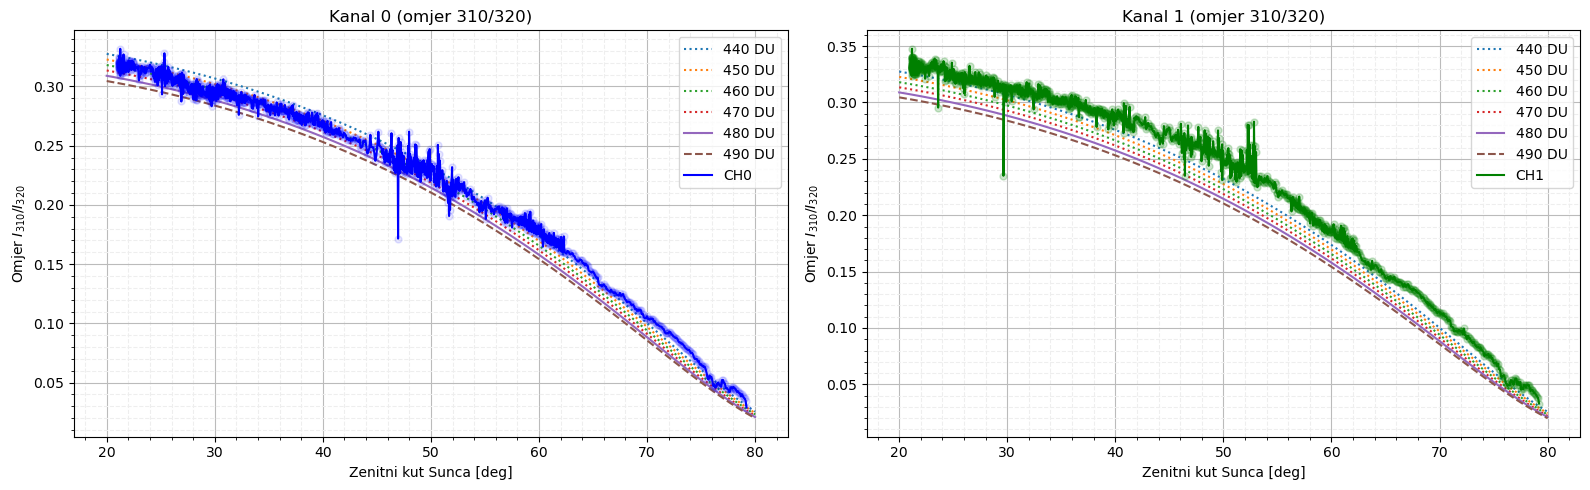

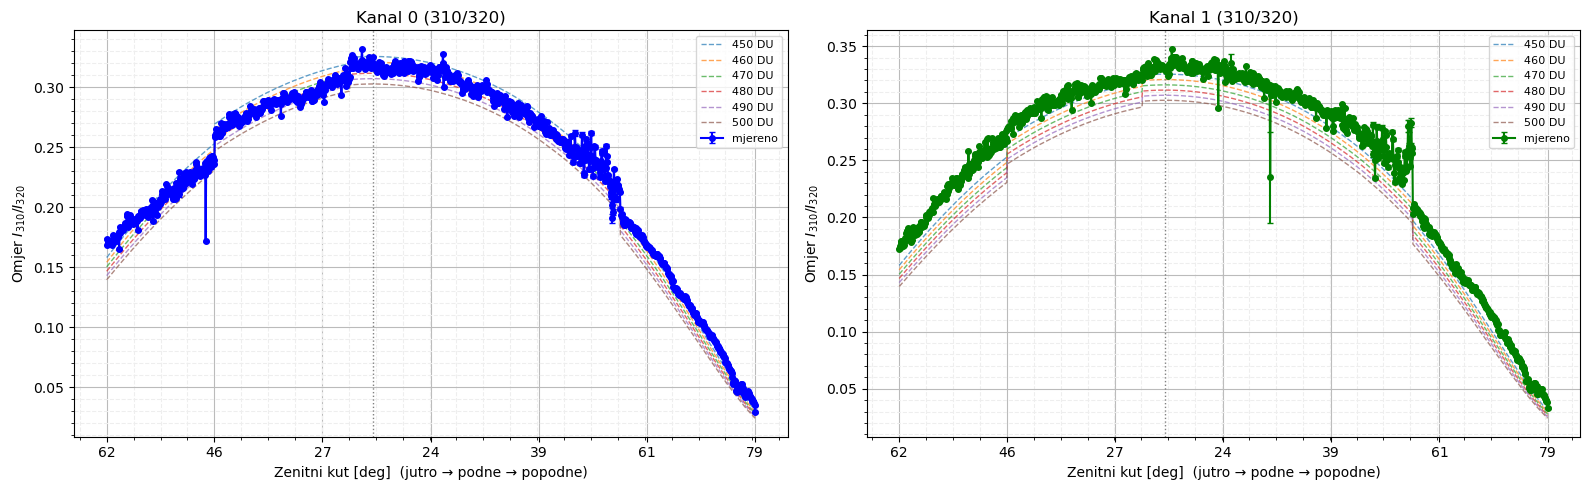

In [45]:
#####~~~~~~~~~~ Omjer 310/320 zasebno po kanalu (dva grafa) ~~~~~~~~~~#####

def filter_switch_per_channel(fname):
    df = pd.read_csv(fname, encoding='utf-16', skiprows=4)
    df.columns = [c.strip() for c in df.columns]
    rows = []
    for el, g in df.groupby('elevation', sort=False):
        A = g[g.mean_ch0 > g.mean_ch1]   # 320 nm nad ch0, 310 nm nad ch1
        B = g[g.mean_ch0 < g.mean_ch1]   # 310 nm nad ch0, 320 nm nad ch1
        if len(A) < 2 or len(B) < 2:
            continue
        ch0_320, ch0_320e = _side(A.mean_ch0)
        ch0_310, ch0_310e = _side(B.mean_ch0)
        ch1_310, ch1_310e = _side(A.mean_ch1)
        ch1_320, ch1_320e = _side(B.mean_ch1)
        r0  = ch0_310 / ch0_320
        r0e = r0 * np.hypot(ch0_310e/ch0_310, ch0_320e/ch0_320)
        r1  = ch1_310 / ch1_320
        r1e = r1 * np.hypot(ch1_310e/ch1_310, ch1_320e/ch1_320)
        rows.append((90 - el, r0, r0e, r1, r1e))
    return np.array(rows)

files = ['mjerenje-25-6-TCP-%d.csv' % n for n in range(1, 5)]
pc = np.vstack([filter_switch_per_channel(f) for f in files])
pc = pc[np.argsort(pc[:, 0])]
z_pc = pc[:, 0]
r0_pc, r0e_pc = pc[:, 1], pc[:, 2]
r1_pc, r1e_pc = pc[:, 3], pc[:, 4]

def bin_ratio(z, r, re, step=0.5):
    """Tezinski srednjak omjera po binovima zenitnog kuta sirine `step`."""
    edges = np.arange(np.floor(z.min()), np.ceil(z.max()) + step, step)
    zb, rb, reb = [], [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (z >= lo) & (z < hi)
        if m.sum() == 0:
            continue
        w = 1.0 / re[m]**2
        rmean = np.sum(w * r[m]) / np.sum(w)
        # pogreska bina: veca od statisticke (1/sqrt(sum w)) i rasapa tocaka u binu
        e_stat = np.sqrt(1.0 / np.sum(w))
        e_scat = np.std(r[m]) / np.sqrt(m.sum()) if m.sum() > 1 else 0.0
        zb.append(0.5 * (lo + hi)); rb.append(rmean); reb.append(max(e_stat, e_scat))
    return np.array(zb), np.array(rb), np.array(reb)

z0b, r0b, r0be = bin_ratio(z_pc, r0_pc, r0e_pc)
z1b, r1b, r1be = bin_ratio(z_pc, r1_pc, r1e_pc)

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

ax[0].plot(SZA, R[24], linestyle=':', label="{} DU".format(DU[24]))
ax[0].plot(SZA, R[25], linestyle=':', label="{} DU".format(DU[25]))
ax[0].plot(SZA, R[26], linestyle=':', label="{} DU".format(DU[26]))
ax[0].plot(SZA, R[27], linestyle=':', label="{} DU".format(DU[27]))
ax[0].plot(SZA, R[28], linestyle='-', label="{} DU".format(DU[28]))
ax[0].plot(SZA, R[29], linestyle='--', label="{} DU".format(DU[29]))
ax[0].plot(z_pc, r0_pc, color='blue',linestyle='-',label='CH0')
ax[0].errorbar(z_pc, r0_pc, color='blue',ls='None',marker='o',markersize=5.,alpha=0.1)
#ax[0].errorbar(z0b, r0b, r0be, ls='-', marker='o', ms=5, lw=1.5,
#               color='tab:blue', capsize=3, label='ch1 (bin 0.5°)')
ax[0].set(xlabel='Zenitni kut Sunca [deg]', ylabel='Omjer $I_{310}/I_{320}$',
          title='Kanal 0 (omjer 310/320)')
#ax[0].set(ylim=(0.05,0.36), xlim=(20,75))
ax[0].grid(which='major', color='#bbbbbb', linestyle='-')
ax[0].grid(which='minor', color='#eeeeee', linestyle='--')
ax[0].minorticks_on()
ax[0].legend(loc='best')

ax[1].plot(SZA, R[24], linestyle=':', label="{} DU".format(DU[24]))
ax[1].plot(SZA, R[25], linestyle=':', label="{} DU".format(DU[25]))
ax[1].plot(SZA, R[26], linestyle=':', label="{} DU".format(DU[26]))
ax[1].plot(SZA, R[27], linestyle=':', label="{} DU".format(DU[27]))
ax[1].plot(SZA, R[28], linestyle='-', label="{} DU".format(DU[28]))
ax[1].plot(SZA, R[29], linestyle='--', label="{} DU".format(DU[29]))
ax[1].plot(z_pc, r1_pc, color='green',linestyle='-',label='CH1')
ax[1].errorbar(z_pc, r1_pc, color='green',ls='None',marker='o',markersize=5.,alpha=0.2)
#ax[1].errorbar(z1b, r1b, r1be, ls='-', marker='o', ms=5, lw=1.5,
#               color='tab:green', capsize=3, label='ch1 (bin 0.5°)')
ax[1].set(xlabel='Zenitni kut Sunca [deg]', ylabel='Omjer $I_{310}/I_{320}$',
          title='Kanal 1 (omjer 310/320)')
#ax[1].set(ylim=(0.05,0.36), xlim=(20,75))
ax[1].grid(which='major', color='#bbbbbb', linestyle='-')
ax[1].grid(which='minor', color='#eeeeee', linestyle='--')
ax[1].minorticks_on()
ax[1].legend(loc='best')

plt.tight_layout()
plt.show()

# KRONOLOSKI red (NE sortiramo po zenitu) -> zenit pada do podneva pa opet raste
pc = np.vstack([filter_switch_per_channel(f) for f in files])
z_pc = pc[:, 0]
r0_pc, r0e_pc = pc[:, 1], pc[:, 2]
r1_pc, r1e_pc = pc[:, 3], pc[:, 4]

idx  = np.arange(len(z_pc))      # kronoloska os (zamjena za vrijeme)
noon = int(np.argmin(z_pc))      # solarni podne ~ najmanji zenitni kut

# model R(SZA) interpoliran na stvarni zenit svake tocke -> prati istu V-putanju
def model_at(i):
    return np.interp(z_pc, SZA, R[i])

def panel(ax, r, re, color, title):
    for i in (24,25,26,27,28,29):
        ax.plot(idx, model_at(i), ls='--', lw=1, alpha=.7, label="{} DU".format(DU[i + 1]))
    ax.errorbar(idx, r, re, color=color, ls='-', marker='o', ms=4, capsize=2, label='mjereno')
    ax.axvline(noon, color='gray', ls=':', lw=1)
    # x-os: kronoloska, ali oznake pokazuju zenitni kut (pada pa raste)
    ti = np.linspace(0, len(idx) - 1, 7).astype(int)
    ax.set_xticks(ti); ax.set_xticklabels(['%.0f' % z_pc[k] for k in ti])
    ax.set(xlabel='Zenitni kut [deg]  (jutro \u2192 podne \u2192 popodne)',
           ylabel='Omjer $I_{310}/I_{320}$', title=title)
    ax.grid(which='major', color='#bbbbbb', ls='-')
    ax.grid(which='minor', color='#eeeeee', ls='--'); ax.minorticks_on()
    ax.legend(loc='best', fontsize=8)

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
panel(ax[0], r0_pc, r0e_pc, 'blue',  'Kanal 0 (310/320)')
panel(ax[1], r1_pc, r1e_pc, 'green', 'Kanal 1 (310/320)')
plt.tight_layout(); plt.show(); plt.close(fig)

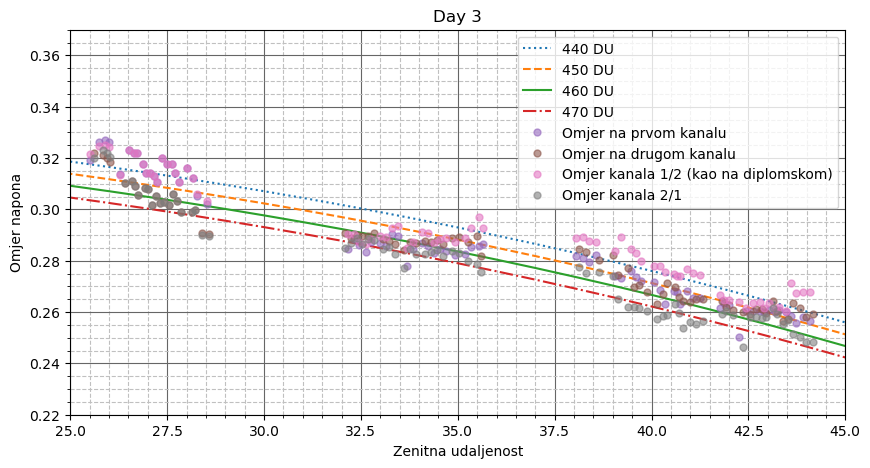

In [ ]:
#####~~~~~~~~~~ MJERENJA LOŠINJ DAN 3 ~~~~~~~~~~#####

meanV1, stdV1, meanV2, stdV2, el = np.loadtxt('MjerenjaLosinj3.txt', delimiter=",",
                                              dtype = 'float', unpack=True,skiprows=4, usecols=[0,1,2,3,5])

psite=29.82*33.86389 # inHg to hPa
I1 = np.array([[integrate.simpson(atmosphere(sza,psite,du,1.66)*detector1,x=wvlgth) for sza in SZA] for du in DU])
I2 = np.array([[integrate.simpson(atmosphere(sza,psite,du,1.66)*detector2,x=wvlgth) for sza in SZA] for du in DU])
RATIO = I1/I2

v1_310 = meanV1[:-1:2]
v1_320 = meanV1[1:-1:2]
v2_310 = meanV2[1:-1:2]
v2_320 = meanV2[:-1:2]

std_v1_310 = stdV1[:-1:2]
std_v1_320 = stdV1[1:-1:2]
std_v2_310 = stdV2[1:-1:2]
std_v2_320 = stdV2[:-1:2]

ratio1 = v1_310 / v1_320
std_r1 = ratio1 * np.sqrt((std_v1_310**2)/(v1_310**2) + (std_v1_320**2)/(v1_320**2))
ratio2 = v2_310 / v2_320
std_r2 = ratio2 * np.sqrt((std_v2_310**2)/(v2_310**2) + (std_v2_320**2)/(v2_320**2))
ratio3 = v1_310 / v2_320
std_r3 = ratio3 * np.sqrt((std_v1_310**2)/(v1_310**2) + (std_v2_320**2)/(v2_320**2))
ratio4 = v2_310 / v1_320
std_r4 = ratio4 * np.sqrt((std_v2_310**2)/(v2_310**2) + (std_v1_320**2)/(v1_320**2))

el_even = el[:-1:2]
el_odd = el[1:-1:2]

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(SZA, RATIO[24], linestyle=':', label="{} DU".format(DU[24]))
ax.plot(SZA, RATIO[25], linestyle='--', label="{} DU".format(DU[25]))
ax.plot(SZA, RATIO[26], linestyle='-', label="{} DU".format(DU[26]))
ax.plot(SZA, RATIO[27], linestyle='-.', label="{} DU".format(DU[27]))
ax.plot(90-el_even, ratio1, ls='None',marker='o',markersize=5., alpha = 0.6, label='Omjer na prvom kanalu')
ax.plot(90-el_odd, ratio2, ls='None',marker='o',markersize=5., alpha = 0.6, label='Omjer na drugom kanalu')
ax.plot(90-el_even, ratio3, ls='None',marker='o',markersize=5., alpha = 0.6, label='Omjer kanala 1/2 (kao na diplomskom)')
ax.plot(90-el_odd, ratio4, ls='None',marker='o',markersize=5., alpha = 0.6, label='Omjer kanala 2/1')
ax.set(ylim=(0.22,0.37), xlim=(25,45))
ax.set(xlabel='Zenitna udaljenost', ylabel='Omjer napona',title='Day 3')
ax.grid( which='major', color='#666666', linestyle='-')
ax.grid(which='minor', color='silver', linestyle='--')
ax.legend(loc='best')
ax.minorticks_on()
plt.show()
plt.close(fig)

In [ ]:
#####~~~~~~~~~~ SIMULACIJA OČEKIVANIH STRUJA I LOG114 POJAČALA ~~~~~~~~~~#####

time, v_log, v_04,v_o5, i1, i2 = np.loadtxt('ozone_log_test.txt', delimiter="\t",
                                  dtype = 'float', unpack=True,skiprows=1)
ratio = i1/i2

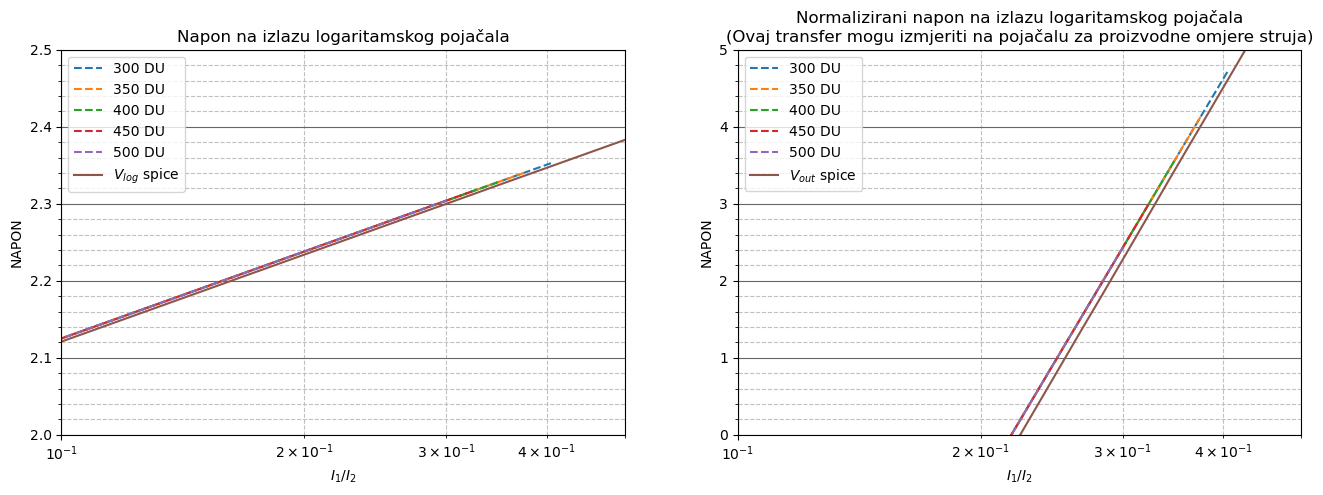

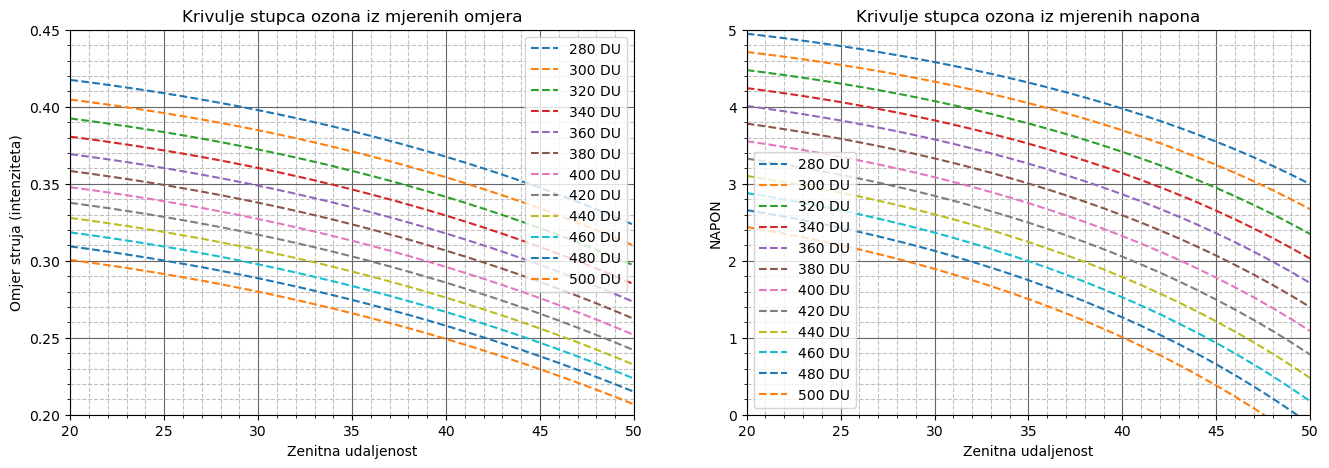

In [ ]:
I1 = np.array([[integrate.simpson(atmosphere(sza,psite,du,1.66)*detector1,x=wvlgth) for sza in SZA] for du in DU])
I2 = np.array([[integrate.simpson(atmosphere(sza,psite,du,1.66)*detector2,x=wvlgth) for sza in SZA] for du in DU])
ratio_sim = I1/I2

v_log_sim = 0.375*np.log10(ratio_sim)+2.5

R1 = 1100
R2 = 0
R3 = 10000
R4 = 1000
R5 = 3650
R6 = 1000
v_int = R4/(R2+R4)*(R1+R3)/R1*v_log_sim - R3/R1*2.5 # simulira interno pojačalo A4 (subtraktor, diferencijalno)
v_out_sim = (1+R5/R6)*v_int                          # simulira interno pojačalo A5 = 1 + 4kOhm/1kOhm (non-inverting)

fig, ax = plt.subplots(1,2,figsize=(16,5))

for i in range(10,len(DU)-10,5):
    ax[0].plot(ratio_sim[i], v_log_sim[i], linestyle='--', label="{} DU".format(DU[i]))
ax[0].plot(ratio, v_log, label='$V_{log}$ spice')
ax[0].set(xlabel='$I_1/I_2$', ylabel='NAPON', title='Napon na izlazu logaritamskog pojačala', 
          xlim=(0.1,0.5), ylim=(2,2.5))
ax[0].set_xscale('log')
ax[0].grid(which='major', color='#666666', linestyle='-')
ax[0].grid(which='minor', color='silver', linestyle='--')
ax[0].minorticks_on()
ax[0].legend(loc='best')

for i in range(10,len(DU)-10,5):
    ax[1].plot(ratio_sim[i], v_out_sim[i], linestyle='--', label="{} DU".format(DU[i]))
ax[1].plot(ratio, v_o5, label='$V_{out}$ spice')
ax[1].set(xlabel='$I_1/I_2$', ylabel='NAPON', title='Normalizirani napon na izlazu logaritamskog pojačala\n(Ovaj transfer mogu izmjeriti na pojačalu za proizvodne omjere struja)'
         , xlim=(0.1,0.5), ylim=(0,5))
ax[1].set_xscale('log')
ax[1].grid(which='major', color='#666666', linestyle='-')
ax[1].grid(which='minor', color='silver', linestyle='--')
ax[1].minorticks_on()
ax[1].legend(loc='best')

plt.show()
plt.close(fig)

fig, ax = plt.subplots(1,2,figsize=(16,5))

for i in range(8,len(DU)-10,2):
    ax[0].plot(SZA, ratio_sim[i], linestyle='--', label="{} DU".format(DU[i]))
ax[0].set(xlabel='Zenitna udaljenost', ylabel='Omjer struja (intenziteta)', title='Krivulje stupca ozona iz mjerenih omjera'
          , xlim=(20,50), ylim=(0.2,0.45))
#ax[0].set_yscale('log')
ax[0].grid(which='major', color='#666666', linestyle='-')
ax[0].grid(which='minor', color='silver', linestyle='--')
ax[0].minorticks_on()
ax[0].legend(loc='best')

for i in range(8,len(DU)-10,2):
    ax[1].plot(SZA, v_out_sim[i], linestyle='--', label="{} DU".format(DU[i]))
ax[1].set(xlabel='Zenitna udaljenost', ylabel='NAPON', title='Krivulje stupca ozona iz mjerenih napona'
         , xlim=(20,50), ylim=(0,5))
ax[1].grid(which='major', color='#666666', linestyle='-')
ax[1].grid(which='minor', color='silver', linestyle='--')
ax[1].minorticks_on()
ax[1].legend(loc='best')

plt.show()
plt.close(fig)

Rezultati simulacije pojačala LOG114 u alatu LT spice:

v_min_log: v(log_out)=2.12288 at 0.0909091 &rarr; v_log za omjer od 0.1\
v_max_log: v(log_out)=2.38499 at 0.49495   &rarr; v_log za omjer od 0.5

v_min4: v(o4)=0.0775199 at 0.0909091       &rarr; v_int za omjer od 0.1\
v_max4: v(o4)=0.950992 at 0.49495          &rarr; v_int za omjer od 0.5

v_min5: v(o5)=0.387579 at 0.0909091        &rarr; v_out za omjer od 0.1\
v_max5: v(o5)=4.75472 at 0.49495           &rarr; v_out za omjer od 0.5

v_log0: v(log_out)=2.49785 at 1            &rarr; napon v_log kada je omjer 1 (treba biti ref napon od 2.5V)\
v_o40: v(o4)=1.32709 at 1                  &rarr; napon v_int kada je omjer 1 (treba biti oko 1.334356V) ; možda koristiti za kalibraciju

Date: Tue Jan  9 17:53:55 2024

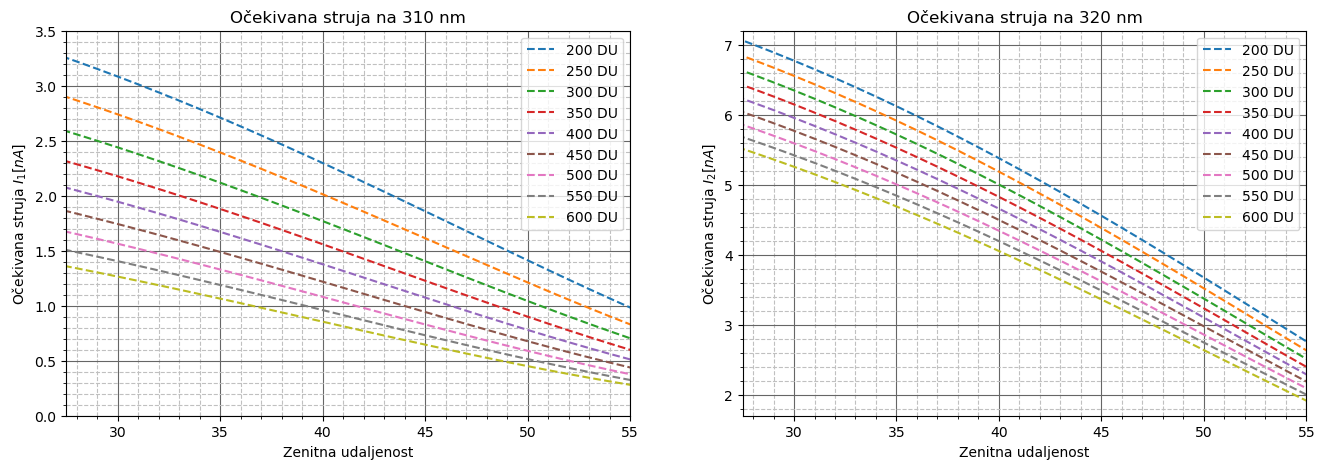

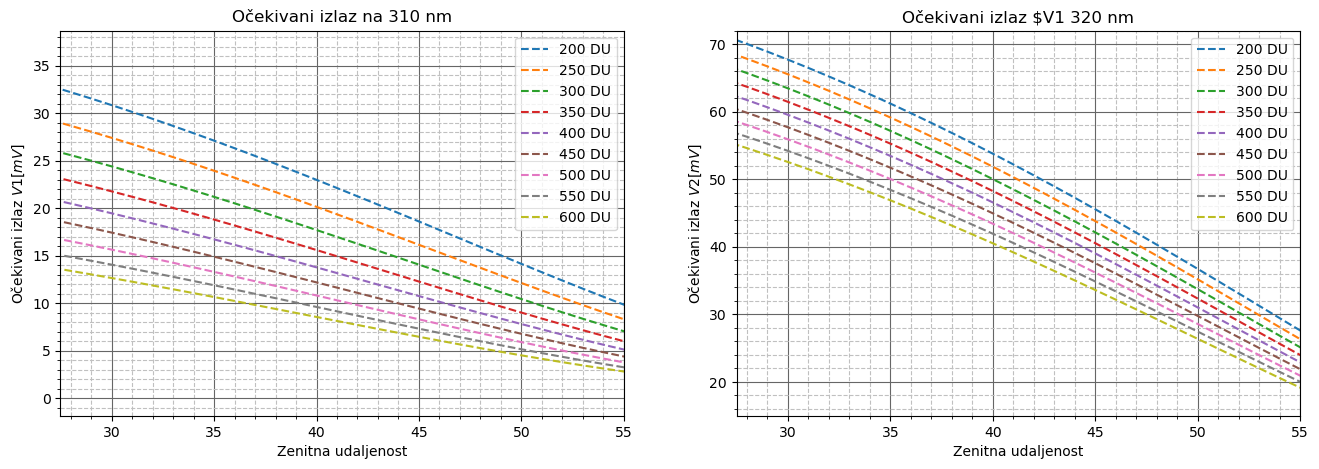

In [ ]:
S = 0.06e-6 # aktivna površina 0.06 mm^2
psite=1017 #29.84*33.86389 # inHg to hPa

I1 = np.array([[S*integrate.simpson(atmosphere(sza,psite,du,1.66)*detector1,x=wvlgth) for sza in SZA] for du in DU]) # u A
I2 = np.array([[S*integrate.simpson(atmosphere(sza,psite,du,1.66)*detector2,x=wvlgth) for sza in SZA] for du in DU]) # u A

fig, ax = plt.subplots(1,2,figsize=(16,5))
for i in range(0,len(DU),5):
    ax[0].plot(SZA, I1[i]*1e9, linestyle='--', label="{} DU".format(DU[i]))
ax[0].set(xlabel='Zenitna udaljenost', ylabel='Očekivana struja $I_1 [nA]$',
          title='Očekivana struja na 310 nm', xlim=(27.5,55), ylim=(0,3.5))
ax[0].grid( which='major', color='#666666', linestyle='-')
ax[0].grid(which='minor', color='silver', linestyle='--')
ax[0].minorticks_on()
ax[0].legend(loc='best')

for i in range(0,len(DU),5):
    ax[1].plot(SZA, I2[i]*1e9, linestyle='--', label="{} DU".format(DU[i]))
ax[1].set(xlabel='Zenitna udaljenost', ylabel='Očekivana struja $I_2 [nA]$',
          title='Očekivana struja na 320 nm', xlim=(27.5,55), ylim=(1.7, 7.2))
ax[1].grid( which='major', color='#666666', linestyle='-')
ax[1].grid(which='minor', color='silver', linestyle='--')
ax[1].minorticks_on()
ax[1].legend(loc='best')

R = 10e6 # 10 MegOhm transimpedance
V1 = I1 * R
V2 = I2 * R

fig, ax = plt.subplots(1,2,figsize=(16,5))
for i in range(0,len(DU),5):
    ax[0].plot(SZA, V1[i]*1e3, linestyle='--', label="{} DU".format(DU[i]))
ax[0].set(xlabel='Zenitna udaljenost', ylabel='Očekivani izlaz $V1 [mV]$',
          title='Očekivani izlaz na 310 nm', xlim=(27.5,55))
ax[0].grid( which='major', color='#666666', linestyle='-')
ax[0].grid(which='minor', color='silver', linestyle='--')
ax[0].minorticks_on()
ax[0].legend(loc='best')

for i in range(0,len(DU),5):
    ax[1].plot(SZA, V2[i]*1e3, linestyle='--', label="{} DU".format(DU[i]))
ax[1].set(xlabel='Zenitna udaljenost', ylabel='Očekivani izlaz $V2 [mV]$',
          title='Očekivani izlaz $V1 320 nm', xlim=(27.5,55), ylim=(15,72))
ax[1].grid( which='major', color='#666666', linestyle='-')
ax[1].grid(which='minor', color='silver', linestyle='--')
ax[1].minorticks_on()
ax[1].legend(loc='best')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# [Channel 1, Channel 2, Sun elevation]

# Measurement 11.5.2024., Dugo Selo
M1 = np.array([[1.275,4.414,62.1], [4.664,1.238,62.1], [1.202,4.302,62.05], [4.653,1.187,62.05],
              [1.181,4.353,62], [4.626,1.203,62], [1.096,4.261,61.9], [4.412,1.055,61.9],
              [1.130,4.190,61.8], [4.446,1.057,61.8], [1.116,4.232,61.75], [4.520,1.109,61.75],
              [1.162,4.287,61.7], [4.524,1.090,61.7], [1.102,4.218,61.6,], [4.523,1.095,61.6]])

Z1 = 90 - M1[1::2, 2] # Zenith angles

# Extract odd rows and compute the ratios of first and second elements
# Measurements with filters in position 310-320
position_1 = M1[::2]
ratios_1 = position_1[:, 0] / position_1[:, 1]

# Extract even rows and compute the ratios of second and first elements
# Measurements with filters in position 320-310
position_2 = M1[1::2]
ratios_2 = position_2[:, 1] / position_2[:, 0]

print("Measurements with filters in position 310-320:")
print(ratios_1)
print("\nMeasurements with filters in position 320-310:")
print(ratios_2)

# Calculate ratios of same channels
channel_1 = M1[::2, 0] / M1[1::2, 0]  # Ratio of first element in odd row to first element in next row
channel_2 = M1[1::2, 1] / M1[:-1:2, 1]  # Ratio of second element in even row to second element in previous row

print("\nRatios of channel 1:")
print(channel_1)
print("\nRatios of channel 2:")
print(channel_2)

err = np.abs(channel_1 - channel_2)
print("\nError:")
print(err)

Measurements with filters in position 310-320:
[0.28885365 0.27940493 0.27130714 0.25721662 0.26968974 0.2637051
 0.27105202 0.26126126]

Measurements with filters in position 320-310:
[0.26543739 0.25510423 0.26005188 0.23912058 0.23774179 0.24535398
 0.24093722 0.24209595]

Ratios of channel 1:
[0.2733705  0.25832796 0.25529615 0.24841342 0.25416104 0.24690265
 0.25685234 0.2436436 ]

Ratios of channel 2:
[0.28047123 0.27591818 0.27636113 0.24759446 0.2522673  0.26205104
 0.25425706 0.25960171]

Error:
[0.00710073 0.01759022 0.02106498 0.00081896 0.00189374 0.01514838
 0.00259529 0.01595811]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# [Channel 1, Channel 2, Sun elevation]

# Measurement 11.5.2024., Dugo Selo
M2 = np.array([[1.068,4.026,61.93], [4.334,0.976,61.93], [0.990,4.074,62.1], [4.239,0.918,62.1],
               [0.973,3.986,62.16], [4.286,0.962,62.16], [1.119,4.186,62.22], [4.222,0.896,62.22],
               [0.939,4.010,62.3], [4.335,0.961,62.3], [0.878,3.884,62.35], [4.374,1.039,62.35],
               [0.909,3.893,62.4], [4.071,0.881,62.4], [0.866,3.778,62.45], [4.198,0.875,62.45]])

Z2 = 90 - M2[1::2, 2] # Zenith angles

# Extract odd rows and compute the ratios of first and second elements
# Measurements where filters were in position 310-320
position_1 = M2[::2]
ratios_1 = position_1[:, 0] / position_1[:, 1]

# Extract even rows and compute the ratios of second and first elements
# Measurements where filters were in position 320-310
position_2 = M2[1::2]
ratios_2 = position_2[:, 1] / position_2[:, 0]

print("Measurements where filters were in position 310-320:")
print(ratios_1)
print("\nMeasurements where filters were in position 320-310:")
print(ratios_2)

# Calculate ratios of same channels
channel_1 = M2[::2, 0] / M2[1::2, 0]  # Ratio of first element in odd row to first element in next row
channel_2 = M2[1::2, 1] / M2[:-1:2, 1]  # Ratio of second element in even row to second element in previous row

print("\nRatios of channel 1:")
print(channel_1)
print("\nRatios of channel 2:")
print(channel_2)

err = np.abs(channel_1 - channel_2)
print("\nError:")
print(err)

Measurements where filters were in position 310-320:
[0.26527571 0.24300442 0.24410437 0.26731964 0.23416459 0.22605561
 0.23349602 0.22922181]

Measurements where filters were in position 320-310:
[0.22519612 0.21656051 0.2244517  0.2122217  0.22168397 0.23754001
 0.21640874 0.20843259]

Ratios of channel 1:
[0.24642363 0.23354565 0.2270182  0.26504027 0.216609   0.2007316
 0.22328666 0.20628871]

Ratios of channel 2:
[0.24242424 0.22533137 0.24134471 0.21404682 0.23965087 0.26750772
 0.22630362 0.23160402]

Error:
[0.00399938 0.00821428 0.01432651 0.05099344 0.02304188 0.06677613
 0.00301696 0.02531531]


In [ ]:
print(Z1)
print(Z2)

[27.9  27.95 28.   28.1  28.2  28.25 28.3  28.4 ]
[28.07 27.9  27.84 27.78 27.7  27.65 27.6  27.55]


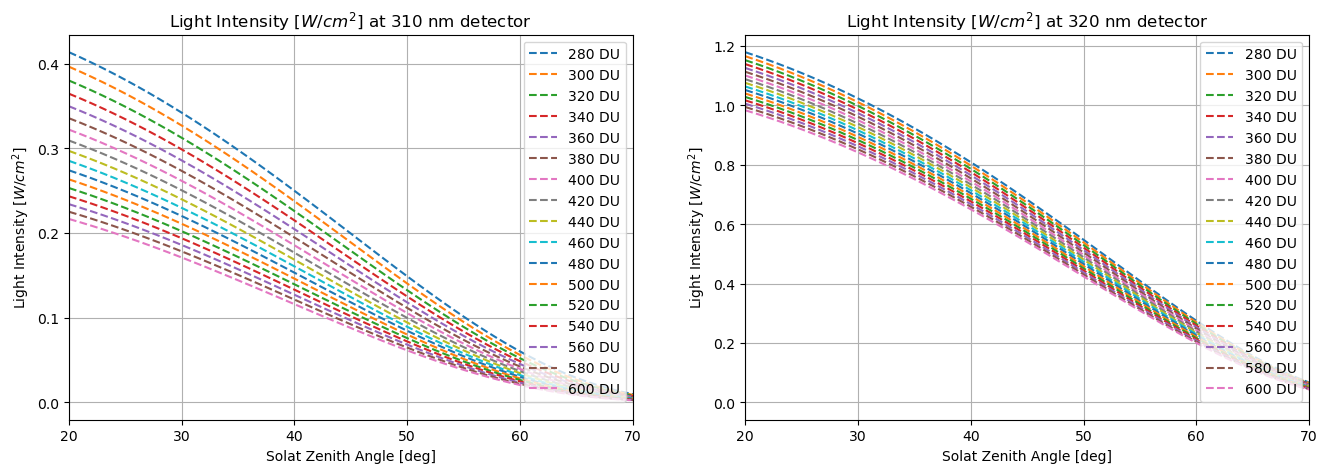

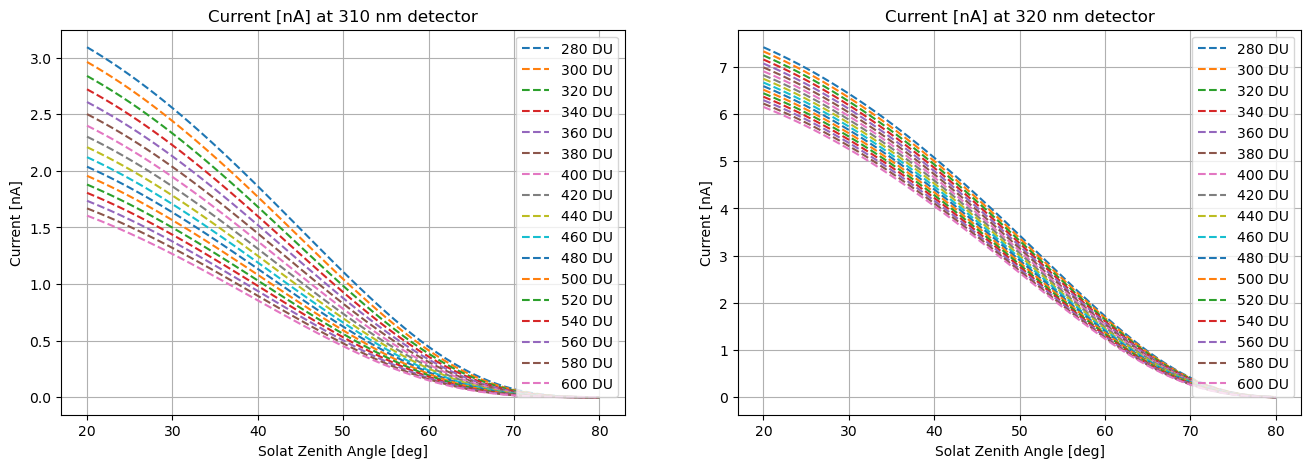

In [ ]:
S = 0.06e-6 # aktivna površina 0.06 mm^2
psite=1017 #29.84*33.86389 # inHg to hPa

IRR1 = np.array([[integrate.simpson(atmosphere(sza,psite,du,1.66)*H1,x=wvlgth) for sza in SZA] for du in DU]) # u W
IRR2 = np.array([[integrate.simpson(atmosphere(sza,psite,du,1.66)*H2,x=wvlgth) for sza in SZA] for du in DU]) # u W

I1 = np.array([[S*integrate.simpson(atmosphere(sza,psite,du,1.66)*detector1,x=wvlgth) for sza in SZA] for du in DU])*1e9 # u nA
I2 = np.array([[S*integrate.simpson(atmosphere(sza,psite,du,1.66)*detector2,x=wvlgth) for sza in SZA] for du in DU])*1e9 # u nA

fig, ax = plt.subplots(1,2,figsize=(16,5))

for i in range(8,len(DU),2):
    ax[0].plot(SZA, IRR1[i], linestyle='--', label="{} DU".format(DU[i]))
ax[0].set(xlabel='Solat Zenith Angle [deg]', ylabel='Light Intensity [$W/cm^2$]',title='Light Intensity [$W/cm^2$] at 310 nm detector',
          xlim=(20,70))
ax[0].grid()
ax[0].legend(loc='best')

for i in range(8,len(DU),2):
    ax[1].plot(SZA, IRR2[i], linestyle='--', label="{} DU".format(DU[i]))
ax[1].set(xlabel='Solat Zenith Angle [deg]', ylabel='Light Intensity [$W/cm^2$]',title='Light Intensity [$W/cm^2$] at 320 nm detector',
          xlim=(20,70))
ax[1].grid()
ax[1].legend(loc='best')

plt.show()
plt.close(fig)        
        
fig, ax = plt.subplots(1,2,figsize=(16,5))

for i in range(8,len(DU),2):
    ax[0].plot(SZA, I1[i], linestyle='--', label="{} DU".format(DU[i]))
ax[0].set(xlabel='Solat Zenith Angle [deg]', ylabel='Current [nA]',title='Current [nA] at 310 nm detector')
          #xlim=(),ylim=())
ax[0].grid()
ax[0].legend(loc='best')

for i in range(8,len(DU),2):
    ax[1].plot(SZA, I2[i], linestyle='--', label="{} DU".format(DU[i]))
ax[1].set(xlabel='Solat Zenith Angle [deg]', ylabel='Current [nA]',title='Current [nA] at 320 nm detector')
         # xlim=(),ylim=())
ax[1].grid()
ax[1].legend(loc='best')

plt.show()
plt.close(fig)

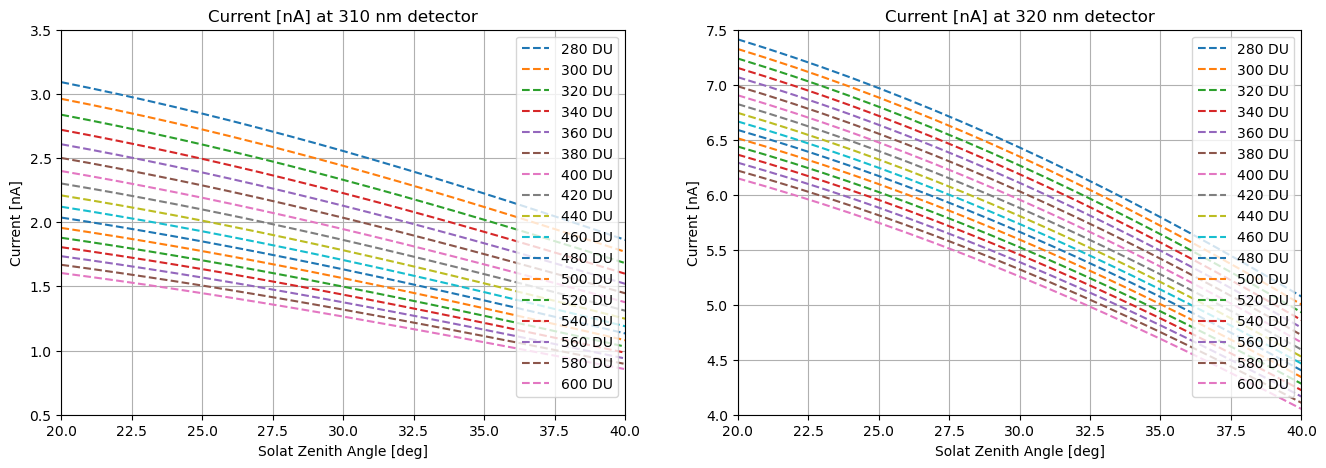

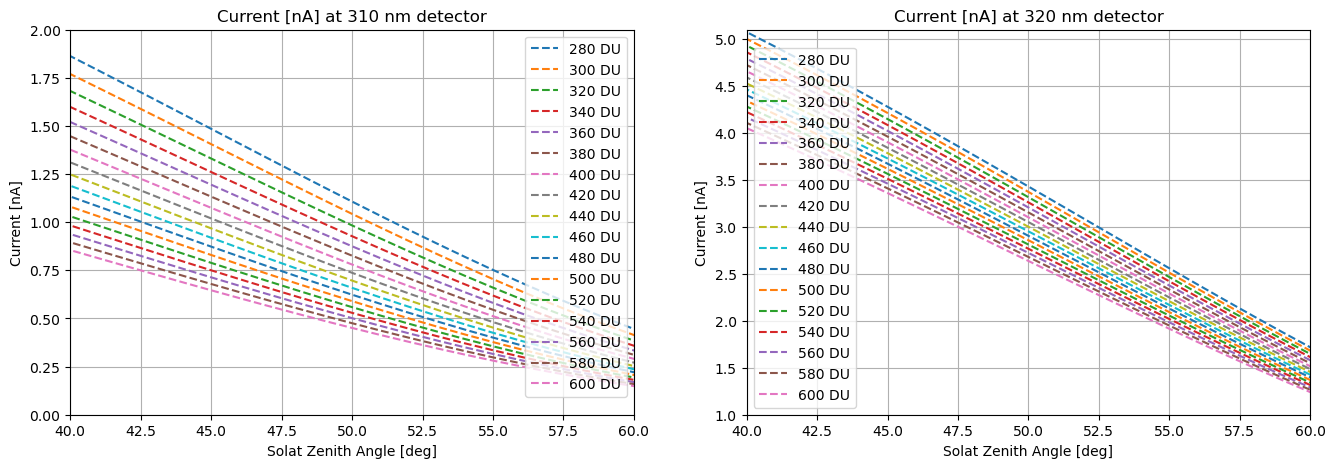

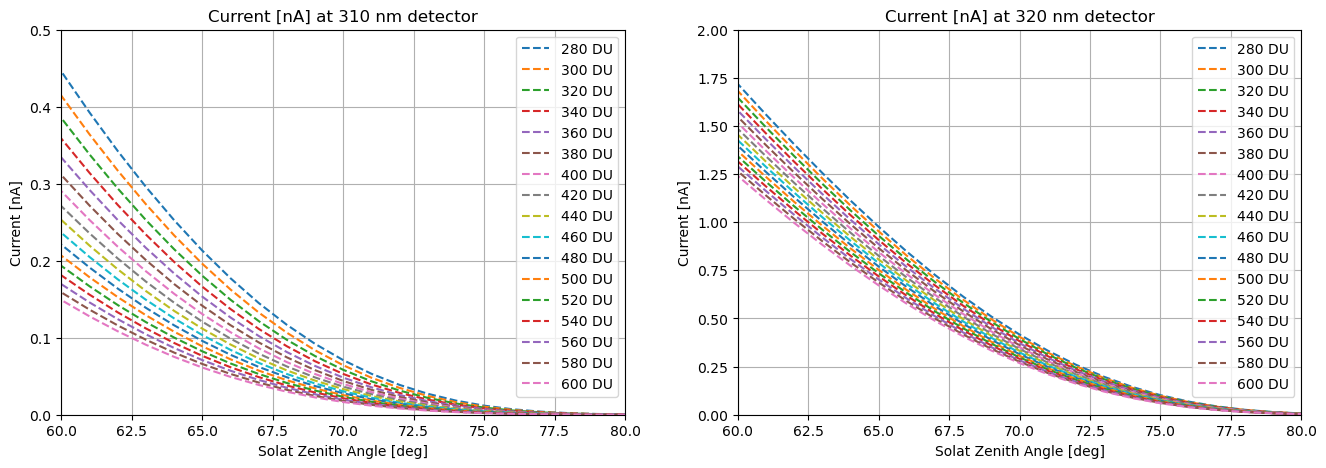

In [ ]:
fig, ax = plt.subplots(1,2,figsize=(16,5))

for i in range(8,len(DU),2):
    ax[0].plot(SZA, I1[i], linestyle='--', label="{} DU".format(DU[i]))
ax[0].set(xlabel='Solat Zenith Angle [deg]', ylabel='Current [nA]',title='Current [nA] at 310 nm detector',
          xlim=(20,40), ylim=(0.5,3.5))
ax[0].grid()
ax[0].legend(loc='best')

for i in range(8,len(DU),2):
    ax[1].plot(SZA, I2[i], linestyle='--', label="{} DU".format(DU[i]))
ax[1].set(xlabel='Solat Zenith Angle [deg]', ylabel='Current [nA]',title='Current [nA] at 320 nm detector',
          xlim=(20,40), ylim=(4,7.5))
ax[1].grid()
ax[1].legend(loc='best')

fig, ax = plt.subplots(1,2,figsize=(16,5))

for i in range(8,len(DU),2):
    ax[0].plot(SZA, I1[i], linestyle='--', label="{} DU".format(DU[i]))
ax[0].set(xlabel='Solat Zenith Angle [deg]', ylabel='Current [nA]',title='Current [nA] at 310 nm detector',
          xlim=(40,60), ylim=(0,2))
ax[0].grid()
ax[0].legend(loc='best')

for i in range(8,len(DU),2):
    ax[1].plot(SZA, I2[i], linestyle='--', label="{} DU".format(DU[i]))
ax[1].set(xlabel='Solat Zenith Angle [deg]', ylabel='Current [nA]',title='Current [nA] at 320 nm detector',
          xlim=(40,60), ylim=(1,5.1))
ax[1].grid()
ax[1].legend(loc='best')

fig, ax = plt.subplots(1,2,figsize=(16,5))

for i in range(8,len(DU),2):
    ax[0].plot(SZA, I1[i], linestyle='--', label="{} DU".format(DU[i]))
ax[0].set(xlabel='Solat Zenith Angle [deg]', ylabel='Current [nA]',title='Current [nA] at 310 nm detector',
          xlim=(60,80), ylim=(0,0.5))
ax[0].grid()
ax[0].legend(loc='best')

for i in range(8,len(DU),2):
    ax[1].plot(SZA, I2[i], linestyle='--', label="{} DU".format(DU[i]))
ax[1].set(xlabel='Solat Zenith Angle [deg]', ylabel='Current [nA]',title='Current [nA] at 320 nm detector',
          xlim=(60,80), ylim=(0,2))
ax[1].grid()
ax[1].legend(loc='best')

plt.show()
plt.close(fig)

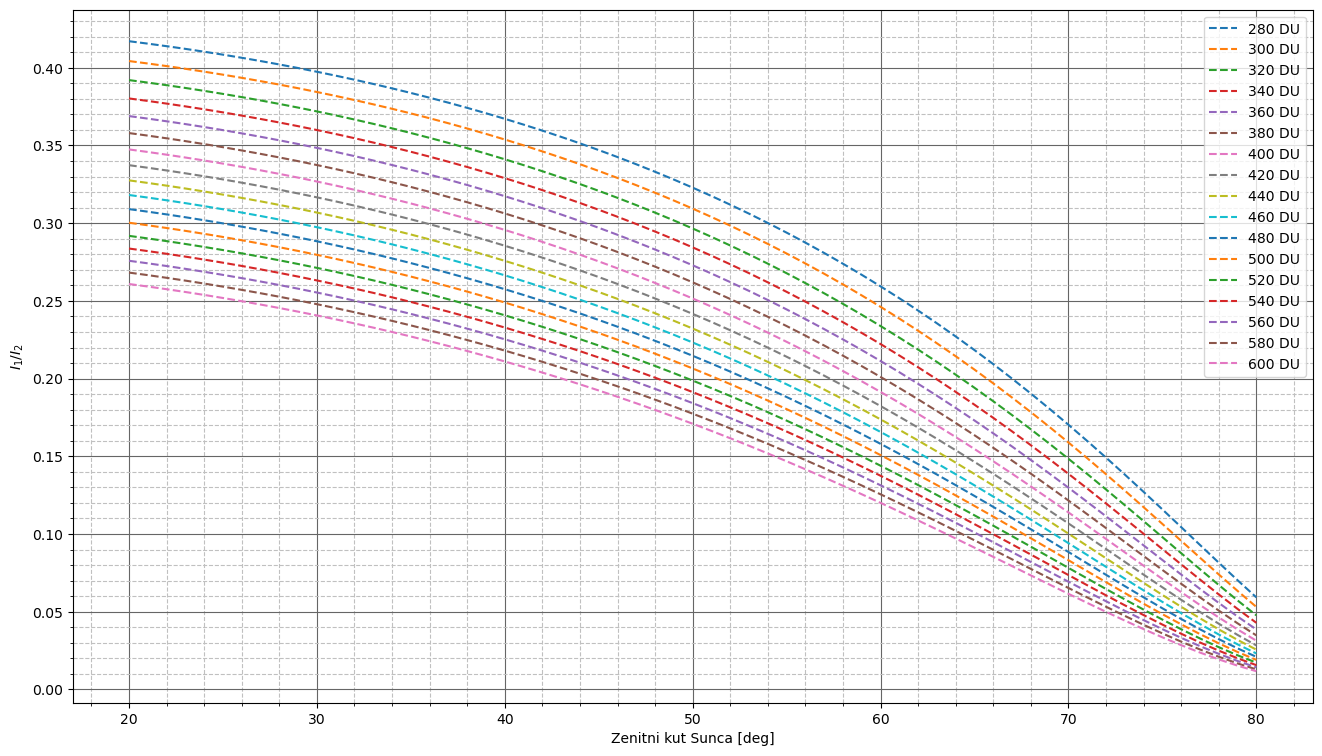

In [ ]:
SZA = np.arange(20,81,1)
DU = np.arange(200,601,10)
psite=30.01*33.86389 # inHg to hPa

I1 = np.array([[integrate.simpson(atmosphere(sza,psite,du)*detector1,x=wvlgth) for sza in SZA] for du in DU])
I2 = np.array([[integrate.simpson(atmosphere(sza,psite,du)*detector2,x=wvlgth) for sza in SZA] for du in DU])
RATIO = I1/I2

fig, ax = plt.subplots(figsize=(16,9))
for i in range(8,len(DU),2):
    ax.plot(SZA, RATIO[i], linestyle='--', label="{} DU".format(DU[i]))
ax.set(xlabel='Zenitni kut Sunca [deg]', ylabel='$I_1/I_2$',title='')
#          xlim=(20,50),ylim=(0.20,0.45))
ax.grid( which='major', color='#666666', linestyle='-')
ax.grid(which='minor', color='silver', linestyle='--')
ax.minorticks_on()
ax.legend(loc='best')

In [ ]:
sza =35
du = 450
psite = 1017 #29.84*33.86389 # inHg to hPa

surf = atmosphere(sza,psite,du,1.66)
r1 = exterre[60]/surf[60]

surf = atmosphere(sza,psite,du,1.66)
r2 = exterre[80]/surf[80]

print(r1,r2)
print(surf[60]/surf[80])

sza =60
psite = 1017 #29.84*33.86389 # inHg to hPa

surf = atmosphere(sza,psite,du,1.66)
r1 = exterre[60]/surf[60]

surf = atmosphere(sza,psite,du,1.66)
r2 = exterre[80]/surf[80]

print(r1,r2)
print(surf[60]/surf[80])

23.947785820955566 8.36140784947013
0.19405197403486585
178.53520648965574 32.16087132961407
0.10011703029336477


array([20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70])

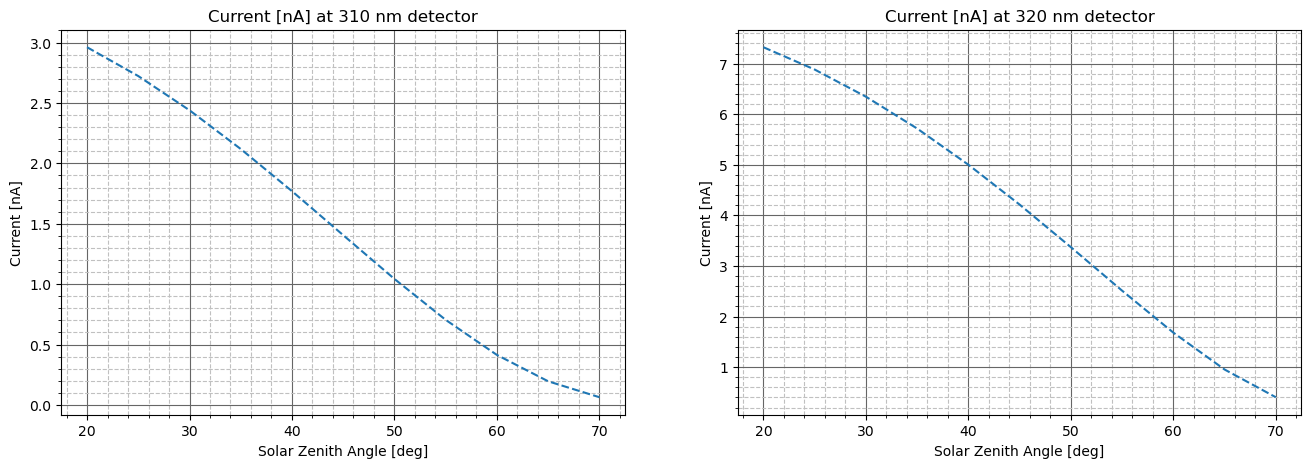

In [ ]:
SZA = np.arange(20,75,5)
du = 300
psite = 1017 #29.84*33.86389 # inHg to hPa
S = 0.06e-6 # aktivna površina 0.06 mm^2

IRR1 = np.array([S*integrate.simpson(atmosphere(sza,psite,du,1.66)*H1,x=wvlgth) for sza in SZA])*1e9 # u nW
IRR2 = np.array([S*integrate.simpson(atmosphere(sza,psite,du,1.66)*H2,x=wvlgth) for sza in SZA])*1e9 # u nW
I1 = np.array([S*integrate.simpson(atmosphere(sza,psite,du)*detector1,x=wvlgth) for sza in SZA])*1e9 # u nA
I2 = np.array([S*integrate.simpson(atmosphere(sza,psite,du)*detector2,x=wvlgth) for sza in SZA])*1e9 # u nA
RATIO = I1/I2

fig, ax = plt.subplots(1,2,figsize=(16,5))
ax[0].plot(SZA, I1, linestyle='--')
ax[0].set(xlabel='Solar Zenith Angle [deg]', ylabel='Current [nA]',title='Current [nA] at 310 nm detector')
ax[1].plot(SZA, I2, linestyle='--')
ax[1].set(xlabel='Solar Zenith Angle [deg]', ylabel='Current [nA]',title='Current [nA] at 320 nm detector')
ax[0].grid( which='major', color='#666666', linestyle='-')
ax[0].grid(which='minor', color='silver', linestyle='--')
ax[0].minorticks_on()
ax[1].grid( which='major', color='#666666', linestyle='-')
ax[1].grid(which='minor', color='silver', linestyle='--')
ax[1].minorticks_on()

SZA

In [ ]:
print("Simulacija promjene struje detektora obzirom na zenitnu udaljenost za 300 DU i 1017 hPa\n")
for i in range(len(SZA)):
    print("When SZA = {0}° : I1 = {1:0.3f} nA, I2 = {2:0.3f} nA, R = {3:0.3f}".format(SZA[i],I1[i],I2[i],RATIO[i]))

Simulacija promjene struje detektora obzirom na zenitnu udaljenost za 300 DU i 1017 hPa

When SZA = 20° : I1 = 2.961 nA, I2 = 7.325 nA, R = 0.404
When SZA = 25° : I1 = 2.723 nA, I2 = 6.884 nA, R = 0.396
When SZA = 30° : I1 = 2.440 nA, I2 = 6.347 nA, R = 0.384
When SZA = 35° : I1 = 2.119 nA, I2 = 5.718 nA, R = 0.371
When SZA = 40° : I1 = 1.770 nA, I2 = 5.002 nA, R = 0.354
When SZA = 45° : I1 = 1.405 nA, I2 = 4.214 nA, R = 0.334
When SZA = 50° : I1 = 1.043 nA, I2 = 3.372 nA, R = 0.309
When SZA = 55° : I1 = 0.704 nA, I2 = 2.512 nA, R = 0.280
When SZA = 60° : I1 = 0.414 nA, I2 = 1.682 nA, R = 0.246
When SZA = 65° : I1 = 0.196 nA, I2 = 0.953 nA, R = 0.206
When SZA = 70° : I1 = 0.064 nA, I2 = 0.404 nA, R = 0.159


In [ ]:
print("Koliko I1 i I2 moraju biti pojačani s promjenom zenitne udaljenosti da se vrate na maksimalni intenzitet za SZA=20°\n")
for i in range(len(SZA)):
    print("SZA = {0}° : gain_I1 = {1:0.2f}, gain_I2 = {2:0.2f}, 1/R aka I2/I1 = {3:0.2f}".format(SZA[i],I1[0]/I1[i],I2[0]/I2[i], I2[i]/I1[i]))

Koliko I1 i I2 moraju biti pojačani s promjenom zenitne udaljenosti da se vrate na maksimalni intenzitet za SZA=20°

SZA = 20° : gain_I1 = 1.00, gain_I2 = 1.00, 1/R aka I2/I1 = 2.47
SZA = 25° : gain_I1 = 1.09, gain_I2 = 1.06, 1/R aka I2/I1 = 2.53
SZA = 30° : gain_I1 = 1.21, gain_I2 = 1.15, 1/R aka I2/I1 = 2.60
SZA = 35° : gain_I1 = 1.40, gain_I2 = 1.28, 1/R aka I2/I1 = 2.70
SZA = 40° : gain_I1 = 1.67, gain_I2 = 1.46, 1/R aka I2/I1 = 2.83
SZA = 45° : gain_I1 = 2.11, gain_I2 = 1.74, 1/R aka I2/I1 = 3.00
SZA = 50° : gain_I1 = 2.84, gain_I2 = 2.17, 1/R aka I2/I1 = 3.23
SZA = 55° : gain_I1 = 4.20, gain_I2 = 2.92, 1/R aka I2/I1 = 3.57
SZA = 60° : gain_I1 = 7.15, gain_I2 = 4.35, 1/R aka I2/I1 = 4.06
SZA = 65° : gain_I1 = 15.11, gain_I2 = 7.69, 1/R aka I2/I1 = 4.86
SZA = 70° : gain_I1 = 46.08, gain_I2 = 18.11, 1/R aka I2/I1 = 6.29


In [ ]:
def roundPartial (value, resolution):
    return round (value / resolution) * resolution

resolution = 180e-6
sza = 60
DU = np.arange(480, 492, 2)
psite = 1017 #29.84*33.86389 # inHg to hPa

IRR1 = np.array([integrate.simpson(atmosphere(sza,psite,du,1.66)*H1,x=wvlgth) for du in DU]) # u W
IRR2 = np.array([integrate.simpson(atmosphere(sza,psite,du,1.66)*H2,x=wvlgth) for du in DU]) # u W
print("SZA = 60 deg\n")
for i in range(len(DU)):
    print("DU = {0} : IRR_310 = {1:0.3f} mW/cm^2, IRR2 = {2:0.3f} mW/cm^2".format(DU[i], IRR1[i]*1e3, IRR2[i]*1e3))
    print("Ratio = {0:0.3f}, TOCON ratio = {1:0.3f}, ABS error = {2:0.5f}".format(IRR1[i]/IRR2[i], 
                                                            roundPartial(IRR1[i],resolution)/roundPartial(IRR2[i],resolution),
                                                            np.abs(IRR1[i]/IRR2[i]-roundPartial(IRR1[i],resolution)/roundPartial(IRR2[i],resolution))))
print("\nRazlika intenziteta za promjenu od 2 DU:\n")
for i in range(len(DU)):
    if i==0:
        continue
    print("delta_DU = {0}-{1} : delta_IRR_310 = {2:0.3f} uW/cm^2, delta_IRR2 = {3:0.3f} uW/cm^2"
          .format(DU[i-1], DU[i], (IRR1[i-1]-IRR1[i])*1e6, (IRR2[i-1]-IRR2[i])*1e6))

SZA = 60 deg

DU = 480 : IRR_310 = 30.023 mW/cm^2, IRR2 = 225.133 mW/cm^2
Ratio = 0.133, TOCON ratio = 0.133, ABS error = 0.00014
DU = 482 : IRR_310 = 29.824 mW/cm^2, IRR2 = 224.694 mW/cm^2
Ratio = 0.133, TOCON ratio = 0.133, ABS error = 0.00028
DU = 484 : IRR_310 = 29.627 mW/cm^2, IRR2 = 224.255 mW/cm^2
Ratio = 0.132, TOCON ratio = 0.132, ABS error = 0.00031
DU = 486 : IRR_310 = 29.431 mW/cm^2, IRR2 = 223.818 mW/cm^2
Ratio = 0.131, TOCON ratio = 0.132, ABS error = 0.00044
DU = 488 : IRR_310 = 29.237 mW/cm^2, IRR2 = 223.381 mW/cm^2
Ratio = 0.131, TOCON ratio = 0.131, ABS error = 0.00034
DU = 490 : IRR_310 = 29.044 mW/cm^2, IRR2 = 222.946 mW/cm^2
Ratio = 0.130, TOCON ratio = 0.130, ABS error = 0.00033

Razlika intenziteta za promjenu od 2 DU:

delta_DU = 480-482 : delta_IRR_310 = 198.728 uW/cm^2, delta_IRR2 = 439.645 uW/cm^2
delta_DU = 482-484 : delta_IRR_310 = 197.259 uW/cm^2, delta_IRR2 = 438.570 uW/cm^2
delta_DU = 484-486 : delta_IRR_310 = 195.803 uW/cm^2, delta_IRR2 = 437.499 uW/cm^

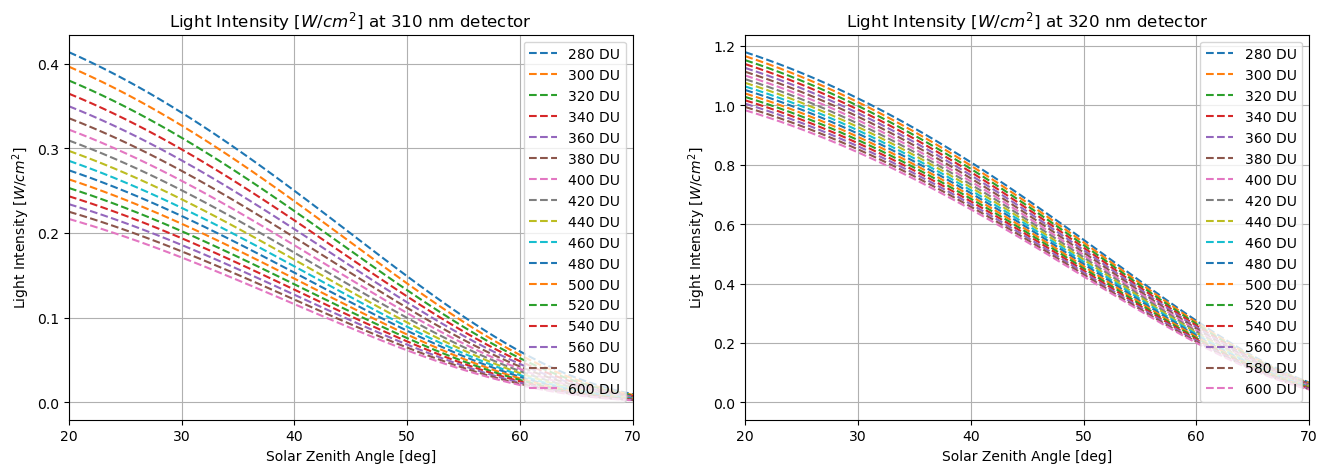

In [ ]:
SZA = np.arange(20,81,1)
DU = np.arange(200,601,10)

psite=1017 #29.84*33.86389 # inHg to hPa

IRR1 = np.array([[integrate.simpson(atmosphere(sza,psite,du,1.66)*H1,x=wvlgth) for sza in SZA] for du in DU]) # u W
IRR2 = np.array([[integrate.simpson(atmosphere(sza,psite,du,1.66)*H2,x=wvlgth) for sza in SZA] for du in DU]) # u W

fig, ax = plt.subplots(1,2,figsize=(16,5))

for i in range(8,len(DU),2):
    ax[0].plot(SZA, IRR1[i], linestyle='--', label="{} DU".format(DU[i]))
ax[0].set(xlabel='Solar Zenith Angle [deg]', ylabel='Light Intensity [$W/cm^2$]',title='Light Intensity [$W/cm^2$] at 310 nm detector',
          xlim=(20,70))
ax[0].grid()
ax[0].legend(loc='best')

for i in range(8,len(DU),2):
    ax[1].plot(SZA, IRR2[i], linestyle='--', label="{} DU".format(DU[i]))
ax[1].set(xlabel='Solar Zenith Angle [deg]', ylabel='Light Intensity [$W/cm^2$]',title='Light Intensity [$W/cm^2$] at 320 nm detector',
          xlim=(20,70))
ax[1].grid()
ax[1].legend(loc='best')

plt.show()
plt.close(fig)  

In [ ]:
psite = 1017 #29.84*33.86389 # inHg to hPa
du = 300
sza = 45

IRR1 = integrate.simpson(atmosphere(sza,psite,du,1.66)*H1,x=wvlgth)*1e-4 # u W/cm2
IRR2 = integrate.simpson(atmosphere(sza,psite,du,1.66)*H2,x=wvlgth)*1e-4 # u W/cm2

IRR1, IRR2

(1.8871215389100333e-05, 6.721412064693524e-05)

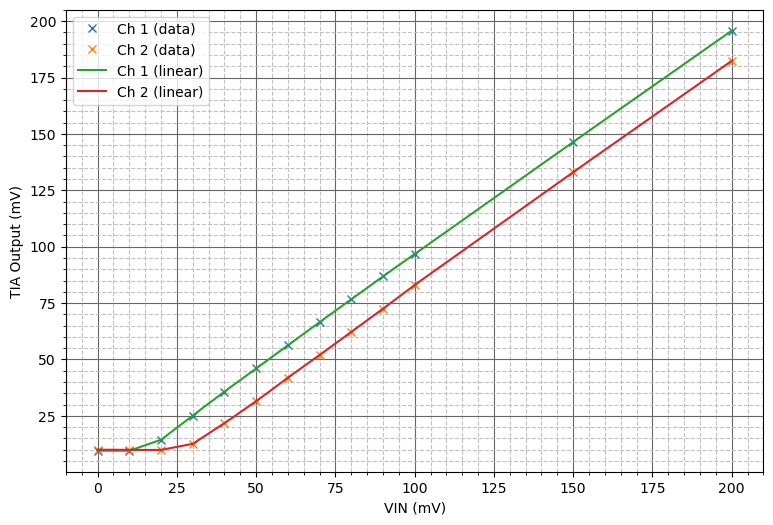

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate

VIN = np.array([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 150, 200])
TIA1 = np.array([9.54, 9.52, 14.36, 25.12, 35.72, 46.00, 56.33, 66.52, 76.68, 86.86, 96.71, 146.46, 195.77])
TIA2 = np.array([9.97, 9.86, 9.86, 12.54, 21.71, 31.45, 41.91, 51.92, 62.17, 72.47, 83.02, 133.06, 182.40])

tck1 = interpolate.splrep(VIN, TIA1, k=1, s=0)
tck2 = interpolate.splrep(VIN, TIA2, k=1, s=0)

xnew = np.linspace(VIN.min(), VIN.max(), 500)

fig, ax = plt.subplots(figsize=(9,6))

ax.plot(VIN, TIA1, 'x', label='Ch 1 (data)')
ax.plot(VIN, TIA2, 'x', label='Ch 2 (data)')
ax.plot(xnew, interpolate.splev(xnew, tck1), label='Ch 1 (linear)')
ax.plot(xnew, interpolate.splev(xnew, tck2), label='Ch 2 (linear)')

ax.grid(which='major', color='#666666', linestyle='-')
ax.grid(which='minor', color='silver', linestyle='--')
ax.minorticks_on()
ax.legend(loc='best')
ax.set_xlabel("VIN (mV)")
ax.set_ylabel("TIA Output (mV)")

plt.show()

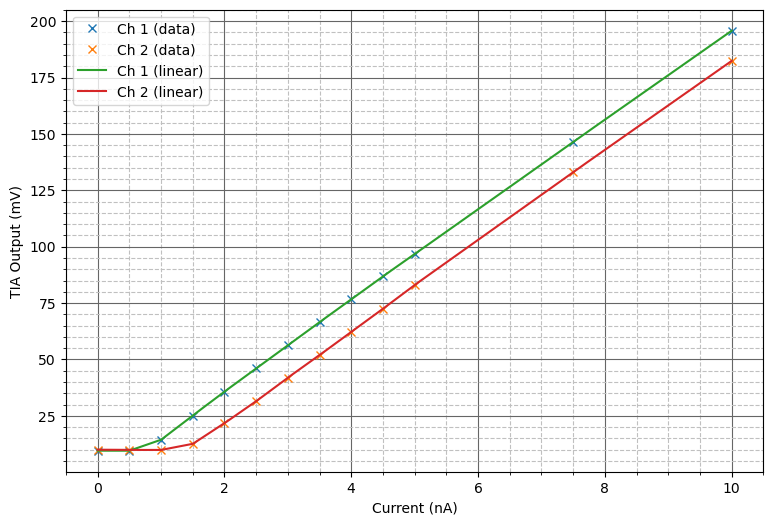

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate

VIN = np.array([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 150, 200])
TIA1 = np.array([9.54, 9.52, 14.36, 25.12, 35.72, 46.00, 56.33, 66.52, 76.68, 86.86, 96.71, 146.46, 195.77])
TIA2 = np.array([9.97, 9.86, 9.86, 12.54, 21.71, 31.45, 41.91, 51.92, 62.17, 72.47, 83.02, 133.06, 182.40])

tck1 = interpolate.splrep(VIN/20, TIA1, k=1, s=0)
tck2 = interpolate.splrep(VIN/20, TIA2, k=1, s=0)

xnew = np.linspace(VIN.min()/20, VIN.max()/20, 500)

fig, ax = plt.subplots(figsize=(9,6))

ax.plot(VIN/20, TIA1, 'x', label='Ch 1 (data)')
ax.plot(VIN/20, TIA2, 'x', label='Ch 2 (data)')
ax.plot(xnew, interpolate.splev(xnew, tck1), label='Ch 1 (linear)')
ax.plot(xnew, interpolate.splev(xnew, tck2), label='Ch 2 (linear)')

ax.grid(which='major', color='#666666', linestyle='-')
ax.grid(which='minor', color='silver', linestyle='--')
ax.minorticks_on()
ax.legend(loc='best')
ax.set_xlabel("Current (nA)")
ax.set_ylabel("TIA Output (mV)")

plt.show()